# Task 11: Time Series Modelling and Forecasting (MAP forecasting)

In [118]:
### Import relevant libraries for this report
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

## Introduction

The objective of this research is to develop a prototype, multi-horizon time-series forecasting model capable of predicting Mean Arterial Pressure (MAE) at hourly intervals. In the high-stakes environment of the Intensive Care Unit (ICU), hemodynamic stability is a critical indicator of patient outcomes. However, MAP is volatile depending on patient's condition, influenced by complex interactions between underlying physiology, mechanical ventilation, and rapid pharmacological interventions such as vasopressor titrations.

By accurately forecasting MAP trajectories up to six hours in advance, this research aims to provide a proactive clinical decision-support tool. Such early warnings allow for preemptive stabilisation of a patient's condition before a critical event occurs.

### Modelling Approach
This task benchmarks three distinct modeling architectures to evaluate their predictive performance:
* **Chronos:** An "off-the-shelf" additive forecasting model developed by Amazon.
* **LSTM (Long Short-Term Memory):** A recurrent neural network (RNN) designed to capture long-term temporal dependencies.
* **TFT (Temporal Fusion Transformer):** A state-of-the-art deep learning model that utilises attention mechanisms for multi-horizon forecasting.



## The Dataset
The MIMIC-IV (Medical Information Mart for Intensive Care) [[1](#Ref1)] dataset was selected for this research. It is a comprehensive, publicly available electronic health record (EHR) database sourced from the Beth Israel Deaconess Medical Center.

While the full MIMIC-IV database contains records for tens of thousands of ICU stays, access to the complete repository is restricted to credentialed researchers. For the purposes of this study, we utilized the MIMIC-IV Clinical Database Demo, which provides high-fidelity data for a cohort of 100 patients.

This data will be useful to be able to benchmark and make proof of concept for models that rely on hospital, ICU and patient data to make predictions. To continue this project further would require the full dataset and possibly other source of data from other hospitals to ensure even higher accuracy and validation. 

## Data Exploration, Data Preprocessing and Feature Selection 
This section outlines the essential steps taken to transform the raw clinical data into a modeling-ready format. The focus here is on the core logic and code required for dataset preparation. I previously performed preliminary data exploration to understand the MIMIC-IV dataset more in a playground.ipynb notebook (not submitted as it is not relevant to presentation)

### Data Exploration
The dataset is structured across multiple files and utilizes a long-format schema to accommodate high-dimensional clinical variables. Each record is indexed by an itemid that identifies the specific physiological parameter or intervention, with the corresponding measurement details captured in the value, valuenum, and valueuom shown in the table below:

In [119]:
mimic_path = 'data/mimic-iv-clinical-database-demo-2.2'
chart_df = pd.read_csv(f'{mimic_path}/icu/chartevents.csv')
chart_df.head()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
0,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:45:00,225054,On,NaN,NaN,0.0
1,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:43:00,223769,100,100.0,%,0.0
2,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,223956,Atrial demand,NaN,NaN,0.0
3,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,224866,Yes,NaN,NaN,0.0
4,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:45:00,227341,No,0.0,NaN,0.0


What each itemid corresponds to can be found in the following table, only relevant columns have been extracted:

In [120]:
df_item_converted = pd.read_csv(f'{mimic_path}/icu/d_items.csv')
df_item_converted = df_item_converted[['itemid','label','abbreviation']]
df_item_converted.head()

,itemid,label,abbreviation
0,226228,Gender,Gender
1,226545,Race,Race
2,229877,Suction events (CH),Suction events (CH)
3,229875,Oxygenator visible (CH),Oxygenator visible (CH)
4,229266,Cannula sites visually inspected (ECMO),Cannula sites visually inspected (ECMO)


To simplify the process of converting column name from itemid to its actual label, the dictionary mapping itemid and label is performed

In [172]:
# Create a dictionary mapping the itemid to the full 'label'
id_to_label = dict(zip(df_item_converted['itemid'], df_item_converted['label']))

# Add string versions just in case the pivot table made the column names strings (MAYBE REMOVE THIS?)
id_to_label.update(dict(zip(df_item_converted['itemid'].astype(str), df_item_converted['label'])))

### MAP (Target Variable) Preprocessing

To formulate a clinically coherent time-series prediction problem, we must first isolate the **Mean Arterial Pressure (MAP)** trajectories. MAP is a critical indicator of organ perfusion and serves as our primary continuous outcome. Based on a clinical audit of the `d_items` table, three distinct **itemids** were identified to capture both invasive and non-invasive measurement modalities.

| Item ID | Label | Measurement Method | Clinical Description |
| :--- | :--- | :--- | :--- |
| **220052** | Arterial Blood Pressure mean | **Invasive** | Measured via an arterial line (A-line) catheter, providing continuous, beat-to-beat pressure monitoring. |
| **220181** | Non Invasive Blood Pressure mean | **Non-Invasive** | Measured via an automated blood pressure cuff (oscillometric method), typically at discrete intervals. |
| **225312** | ART BP mean | **Invasive** | An alternative label for invasive arterial monitoring used in specific ICU settings or older records. |

#### Clinical Justification for Feature Engineering for MAP
The integration of both invasive and non-invasive sources is essential to maximize **sampling density** across the cohort. In the ICU, clinicians often switch between these methods based on the patient's stability; failing to include all three IDs would result in gaps in the longitudinal record, complicating the time alignment required for sequence modelling. It is very important to realize that we will prioritise the invasive method when cleaning data as the invasive method is likely to be more accurate than the non invasive method. Also it is assumed that Arterial Blood Pressure mean, ART BP mean are invasive due to the absent of the word non invasive in these two itemid 


In [122]:
## Extraction of MAP data
map_df = chart_df[chart_df['itemid'].isin([220181, 220052, 225312])]
map_df.head()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
65,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-16 00:02:00,220052,58,58.0,mmHg,0.0
107,10005817,20626031,32604416,6770.0,2132-12-16 01:00:00,2132-12-16 01:04:00,220052,63,63.0,mmHg,0.0
123,10005817,20626031,32604416,6770.0,2132-12-16 02:00:00,2132-12-16 02:11:00,220052,58,58.0,mmHg,0.0
139,10005817,20626031,32604416,6770.0,2132-12-16 03:00:00,2132-12-16 03:00:00,220052,59,59.0,mmHg,0.0
170,10005817,20626031,32604416,6770.0,2132-12-16 04:00:00,2132-12-16 04:21:00,220052,66,66.0,mmHg,0.0


In [123]:
# The table is in a long format, so I have to pivot this to wide format
# 1. Convert charttime to proper datetime objects
map_df['charttime'] = pd.to_datetime(map_df['charttime'])

# 2. Pivot the table
df_map_pivoted = pd.pivot_table(
    map_df,
    index=['subject_id', 'hadm_id', 'stay_id', 'caregiver_id', 'charttime'],
    columns='itemid',
    values='valuenum', 
    aggfunc='first' 
)

# 3. Clean up the axis name (optional, but removes the floating 'itemid' label over the index)
df_map_pivoted.columns.name = None

# 4. Flatten the index
df_map_pivoted.reset_index(inplace=True)
# 5. Rename the column to make it easier to understand
df_map_pivoted.rename(columns=id_to_label, inplace=True)
df_map_pivoted.head()


/var/folders/5n/m32d0hsx4959r42x3mssyjj40000gn/T/ipykernel_81718/1575591756.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  map_df['charttime'] = pd.to_datetime(map_df['charttime'])


,subject_id,hadm_id,stay_id,caregiver_id,charttime,Arterial Blood Pressure mean,Non Invasive Blood Pressure mean,ART BP Mean
0,10000032,29079034,39553978,47007.0,2180-07-23 21:01:00,NaN,63.0,NaN
1,10000032,29079034,39553978,47007.0,2180-07-23 22:00:00,NaN,62.0,NaN
2,10000032,29079034,39553978,66056.0,2180-07-23 19:00:00,NaN,56.0,NaN
3,10000032,29079034,39553978,66056.0,2180-07-23 20:00:00,NaN,64.0,NaN
4,10000032,29079034,39553978,88981.0,2180-07-23 14:11:00,NaN,56.0,NaN


In [124]:
# Now we will make a standardise MAP column which prioritises the invasive MAP first 
# 1. Combine the two invasive measurements. 
# It checks the first arterial code, and if missing, checks the second arterial code.
invasive_map = df_map_pivoted['Arterial Blood Pressure mean'].combine_first(df_map_pivoted['ART BP Mean'])

# 2. Create the final standardized 'MAP' column.
# It takes the invasive_map we just made, and if it's STILL missing, 
# it falls back to the non-invasive cuff measurement.
df_map_pivoted['MAP'] = invasive_map.combine_first(df_map_pivoted['Non Invasive Blood Pressure mean'])

# 3. Clean up by dropping the old individual columns so your dataframe stays neat
df_map_pivoted = df_map_pivoted.drop(columns=[
    'Arterial Blood Pressure mean', 
    'ART BP Mean', 
    'Non Invasive Blood Pressure mean'
])
df_map_pivoted.head()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,MAP
0,10000032,29079034,39553978,47007.0,2180-07-23 21:01:00,63.0
1,10000032,29079034,39553978,47007.0,2180-07-23 22:00:00,62.0
2,10000032,29079034,39553978,66056.0,2180-07-23 19:00:00,56.0
3,10000032,29079034,39553978,66056.0,2180-07-23 20:00:00,64.0
4,10000032,29079034,39553978,88981.0,2180-07-23 14:11:00,56.0


In [125]:
# Sort the df_map_pivoted based on subject_id and charttime
df_map_pivoted = df_map_pivoted.sort_values(by=['subject_id','charttime'], ascending=[True, True])
df_map_pivoted.head()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,MAP
4,10000032,29079034,39553978,88981.0,2180-07-23 14:11:00,56.0
5,10000032,29079034,39553978,88981.0,2180-07-23 14:30:00,67.0
6,10000032,29079034,39553978,88981.0,2180-07-23 15:00:00,64.0
7,10000032,29079034,39553978,88981.0,2180-07-23 16:01:00,64.0
8,10000032,29079034,39553978,88981.0,2180-07-23 17:00:00,67.0


Now that we have obtained the MAP values preprocessed and sorted by subject_id and charttime in ascending order, I would like to verify that hourly measurement is the right measure for this task. This is performed by obtaining the average sample interval.

In [126]:
# This result basically presents that I have to do hourly prediction as number is quite close to 60 minutes
def get_average_sampling_interval(df, itemid_col='itemid', time_col='charttime'):
    """
    Calculates the average time (in minutes) between successive measurements
    per patient (stay_id).
    """
    # Ensure time is datetime
    df[time_col] = pd.to_datetime(df[time_col])
    
    # Sort to ensure chronological order
    df = df.sort_values(['stay_id', time_col])
    
    # Calculate difference between rows within each stay_id
    df['time_diff'] = df.groupby('stay_id')[time_col].diff().dt.total_seconds() / 60
    
    # Return average (ignoring NaNs from the first row of each group)
    avg_diff = df['time_diff'].mean()
    
    return avg_diff


avg_map_interval = get_average_sampling_interval(df_map_pivoted)
avg_map_interval

np.float64(51.971309111880046)

As you can see, we have obtained the average sampling interval to be 52 minutes, which justifies that MAP measurement is roughtly taken every hour. This means it is appropriate for this task to use an hourly prediction, as minute prediction would be extremely inaccurate with very sparse data. 

### Static Exogenous Variable incorporation
Before I combined hourly data, I would like to include static exogenous variable that I have identified to be useful for this analysis, which includes the age and gender of the patient

In [127]:
### Static Exogenous Factors
patients_df = pd.read_csv(f'{mimic_path}/hosp/patients.csv')
patients_df = patients_df[['subject_id', 'gender', 'anchor_age', 'anchor_year']]
patients_df.head()

,subject_id,gender,anchor_age,anchor_year
0,10014729,F,21,2125
1,10003400,F,72,2134
2,10002428,F,80,2155
3,10032725,F,38,2143
4,10027445,F,48,2142


#### Dynamic Age Calculation and Feature Encoding

In the MIMIC-IV dataset, patient ages are provided as an `anchor_age` relative to a specific `anchor_year` to completely hide the actual time this event occured to prevent potential leakage of patient's personal information (PII and PHI). To ensure the model receives the most accurate physiological context, we calculate the **True Age** at the time of each ICU admission by adding the difference between the `charttime` year and the `anchor_year` to the patient's baseline age. 

* **Dynamic Age:** Account for the time elapsed between the patient's record "anchor" and their actual clinical presentation.
* **Static Categoricals:** The `gender` feature is mapped to a binary indicator (`gender_female`) for compatibility with the neural network architecture.
* **Data Integrity:** A statistical summary follows to verify that age and gender distributions fall within biologically plausible ranges, confirming no further outlier masking is required for these static attributes.

In [128]:
### Combined static information
# 1. Merge the static patient data onto your hourly time-series dataframe
df_map_static = df_map_pivoted.merge(
    patients_df[['subject_id', 'gender', 'anchor_age', 'anchor_year']], 
    on='subject_id', 
    how='left'
)

# 2. Calculate the true age at the exact time of the ICU stay (refer to above for detailed explanation)
# (Charttime Year - Anchor Year) + Anchor Age
df_map_static['age'] = df_map_static['anchor_age'] + (df_map_static['charttime'].dt.year - df_map_static['anchor_year'])

# 3. Clean up the unneeded columns
df_map_static = df_map_static.drop(columns=['anchor_age', 'anchor_year'])

# 4. Convert Gender to a binary feature for the model (e.g., M = 0, F = 1)
df_map_static['gender_female'] = (df_map_static['gender'] == 'F').astype(int)
df_map_static = df_map_static.drop(columns=['gender'])

# This is just to see that there is no abnormal age and gender_female column, so no outlier handling needed
df_map_static.describe()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,MAP,age,gender_female
count,1.401100e+04,1.401100e+04,1.401100e+04,14011.000000,14011,14011.00000,14011.000000,14011.000000
mean,1.001866e+07,2.514014e+07,3.477848e+07,50057.556777,2148-02-24 22:27:52.257512448,76.50546,63.385768,0.457355
min,1.000003e+07,2.004459e+07,3.005745e+07,199.000000,2110-04-11 16:00:00,-23.00000,21.000000,0.000000
25%,1.000605e+07,2.242920e+07,3.228306e+07,27016.000000,2133-12-22 06:30:00,67.00000,51.000000,0.000000
50%,1.001900e+07,2.454084e+07,3.457802e+07,51292.000000,2145-09-29 09:00:00,75.00000,66.000000,0.000000
75%,1.002641e+07,2.825813e+07,3.729340e+07,73391.000000,2161-04-28 00:30:00,84.00000,75.000000,1.000000
max,1.004002e+07,2.997458e+07,3.988077e+07,99850.000000,2201-12-13 17:00:00,801.00000,92.000000,1.000000
std,1.207900e+04,3.095419e+06,2.904724e+06,27781.459322,NaN,17.42619,15.108459,0.498196


In [129]:
# Resampling to hourly data and aggregating using mean for MAP, and first for static features (since they don't change)
agg_rules_map = {
    'MAP': 'mean',
    'age': 'first', 
    'gender_female': 'first'}

df_map_static_hourly = df_map_static.groupby(['subject_id', 'hadm_id', 'stay_id']).resample('1h', on='charttime').agg(agg_rules_map).reset_index()
df_map_static_hourly.head()

,subject_id,hadm_id,stay_id,charttime,MAP,age,gender_female
0,10000032,29079034,39553978,2180-07-23 14:00:00,61.5,52.0,1.0
1,10000032,29079034,39553978,2180-07-23 15:00:00,64.0,52.0,1.0
2,10000032,29079034,39553978,2180-07-23 16:00:00,64.0,52.0,1.0
3,10000032,29079034,39553978,2180-07-23 17:00:00,67.0,52.0,1.0
4,10000032,29079034,39553978,2180-07-23 18:00:00,60.0,52.0,1.0


#### Removing stay_id with too little data

In [130]:
# It is important to know how much value are in each stay_id, if there is too little value 
df_map_static_hourly.groupby('stay_id')['charttime'].count().sort_values(ascending=True).head(20)

stay_id
36871784     2
36035031     4
33652203     5
39553978     9
30864406    12
36734659    13
38275267    14
35629889    15
35396193    16
35475449    16
38329661    16
32496174    16
39804682    18
39623478    18
30876334    19
37323533    19
31552399    19
32554129    20
38229329    20
37200209    21
Name: charttime, dtype: int64

I have determined that a lookback of 12 hours and a prediction of 6 hours would be the most useful, so we need stay_id with at least 18 data points. This decision was driven by two factors: (1) Physiological Relevance: ICU hemodynamics are highly stochastic; a 12-hour window prioritizes recent acute trajectories over stale historical data. (2) Data Volume: By using the total required sequence length to 18 hours (12 lookback+6 forecast), we did not drop a significant amount of data (~10 stay_id). 

In [131]:
stay_id_counts = df_map_static_hourly.groupby('stay_id')['charttime'].count()
valid_stay_ids = stay_id_counts[stay_id_counts >= 18].index
df_map_static_hourly = df_map_static_hourly[df_map_static_hourly['stay_id'].isin(valid_stay_ids)]
df_map_static_hourly

,subject_id,hadm_id,stay_id,charttime,MAP,age,gender_female
9,10001217,24597018,37067082,2157-11-20 19:00:00,104.0,55.0,1.0
10,10001217,24597018,37067082,2157-11-20 20:00:00,95.0,55.0,1.0
11,10001217,24597018,37067082,2157-11-20 21:00:00,103.0,55.0,1.0
12,10001217,24597018,37067082,2157-11-20 22:00:00,93.0,55.0,1.0
13,10001217,24597018,37067082,2157-11-20 23:00:00,88.0,55.0,1.0
...,...,...,...,...,...,...,...
12207,10040025,27996267,36107367,2148-01-30 12:00:00,86.0,69.0,1.0
12208,10040025,27996267,36107367,2148-01-30 13:00:00,85.0,69.0,1.0
12209,10040025,27996267,36107367,2148-01-30 14:00:00,96.0,69.0,1.0
12210,10040025,27996267,36107367,2148-01-30 15:00:00,80.0,69.0,1.0


#### Handling Outlier and Missing Values

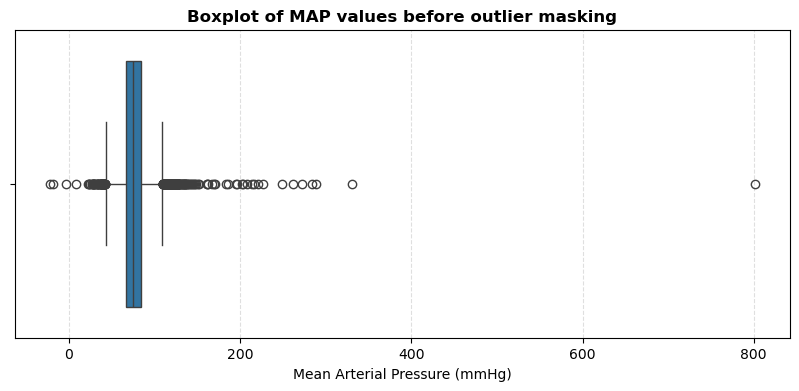

In [132]:
# Visualising outlier in MAP values
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_map_static_hourly['MAP'])
plt.title('Boxplot of MAP values before outlier masking', fontweight='bold')
plt.xlabel('Mean Arterial Pressure (mmHg)')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()


While many data points fall outside the typical range, clinical research [2] suggests that real MAP values are almost always between 10 and 400 mmHg. Because of this, we ignore any values outside this range, like negative numbers or extremely high readings, and treat them as errors. We then use forward-fill to replace these missing spots, ensuring the timeline stays consistent without including impossible data.

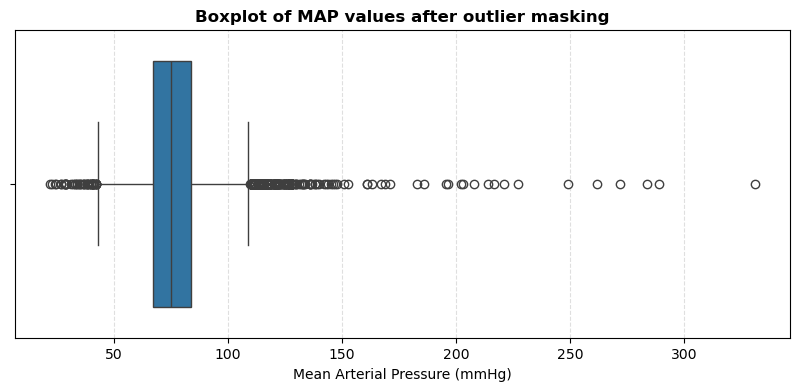

In [133]:
# 1. Mask outliers as NaN (Keeping the rows intact for time-series continuity)
df_map_static_hourly.loc[
    (df_map_static_hourly['MAP'] <= 10) | (df_map_static_hourly['MAP'] >= 400), 
    'MAP'
] = np.nan

# 2. Visualisation 
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_map_static_hourly['MAP'])
plt.title('Boxplot of MAP values after outlier masking', fontweight='bold')
plt.xlabel('Mean Arterial Pressure (mmHg)')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()


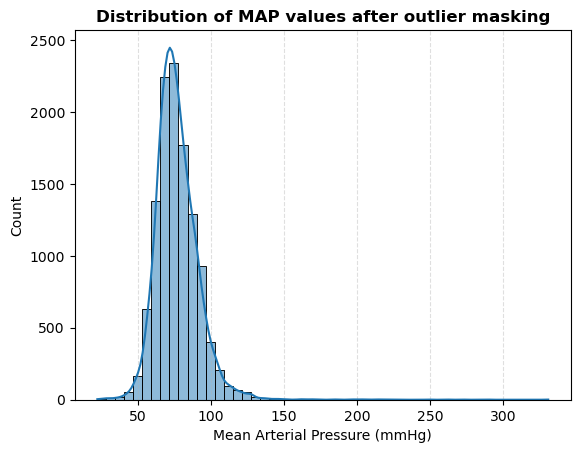

In [134]:
# Check distribution of data to see potential anomaly 
sns.histplot(df_map_static_hourly['MAP'], bins=50, kde=True)
plt.title('Distribution of MAP values after outlier masking', fontweight='bold')
plt.xlabel('Mean Arterial Pressure (mmHg)')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

The data now follows a clean, physiologically normal distribution. Most readings are concentrated between 70 and 90 mmHg, which is the expected healthy range for an ICU patient.

The long "tail" stretching toward the right represents cases of hypertension, while the smaller bump on the left shows episodes of hypotension. By keeping these real clinical variations but removing the extreme errors, the model can now learn the actual patterns of blood pressure changes.

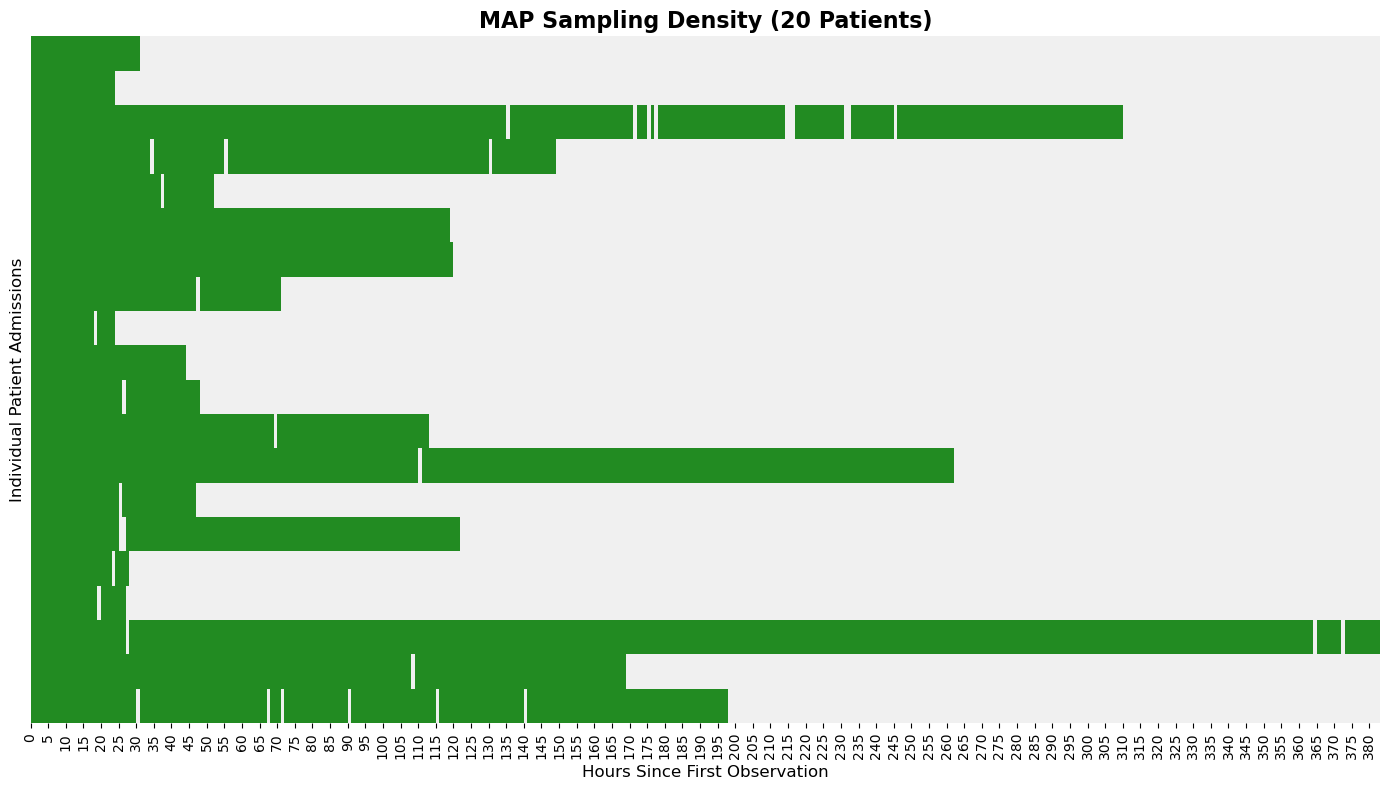

In [135]:
def plot_sampling_density(df, column_name='MAP', n_patients=20, freq=5):
    """
    Generates a longitudinal heatmap showing data presence/missingness.
    
    Parameters:
    - df: The dataframe containing the data.
    - column_name: The column to check for missingness (e.g., 'MAP').
    - n_patients: Number of unique stay_ids to display.
    - freq: Frequency of x-axis ticks (every N hours).
    """
    # 1. Select the top N unique patients
    sample_ids = df['stay_id'].unique()[:n_patients]
    df_sample = df[df['stay_id'].isin(sample_ids)].copy()
    
    # 2. Calculate relative hours (ensures every patient starts at 0)
    # Using rank with 'min' ensures that even if timestamps are weird, 
    # the first observation is always the 0th hour.
    df_sample['hours_since_start'] = (
        df_sample.groupby('stay_id')['charttime']
        .rank(method='min').astype(int) - 1
    )
    
    # 3. Create the pivot table (Binary: 1 if present, 0 if NaN)
    missing_pivot = (
        df_sample.pivot(index='stay_id', columns='hours_since_start', values=column_name)
        .notnull().astype(int)
    )
    
    # 4. Plotting
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        missing_pivot, 
        cbar=False, 
        cmap=['#f0f0f0', '#228b22'], # Grey for Missing, Green for Present
        yticklabels=False
    )
    
    plt.title(f'{column_name} Sampling Density ({n_patients} Patients)', fontweight='bold', fontsize=16)
    plt.xlabel('Hours Since First Observation', fontsize=12)
    plt.ylabel('Individual Patient Admissions', fontsize=12)
    
    # 5. Handle X-ticks dynamically based on the longest stay in the sample
    max_hours = missing_pivot.columns.max()
    plt.xticks(np.arange(0, max_hours + 1, freq), labels=np.arange(0, max_hours + 1, freq))
    
    plt.tight_layout()
    plt.show()

plot_sampling_density(df_map_static_hourly, column_name='MAP', n_patients=20)

While most patients have consistent coverage, the gaps are generally small and scattered, meaning they don't follow a specific problematic pattern. To ensure the models have a continuous timeline to learn from, these missing segments will be handled using forward-fill, which carries the last known valid blood pressure reading forward until a new measurement is taken.

In [136]:
# 1. Set Index to prepare for forward fill
df_map_static_hourly = df_map_static_hourly.set_index(['subject_id', 'hadm_id', 'stay_id', 'charttime'])

# 2. Perform the fill within each stay_id group
df_map_static_hourly = df_map_static_hourly.groupby('stay_id').ffill()

# 3. Bring the IDs back as columns
df_map_static_hourly = df_map_static_hourly.reset_index()
print(df_map_static_hourly.isna().sum())
df_map_static_hourly

subject_id       0
hadm_id          0
stay_id          0
charttime        0
MAP              0
age              0
gender_female    0
dtype: int64


,subject_id,hadm_id,stay_id,charttime,MAP,age,gender_female
0,10001217,24597018,37067082,2157-11-20 19:00:00,104.0,55.0,1.0
1,10001217,24597018,37067082,2157-11-20 20:00:00,95.0,55.0,1.0
2,10001217,24597018,37067082,2157-11-20 21:00:00,103.0,55.0,1.0
3,10001217,24597018,37067082,2157-11-20 22:00:00,93.0,55.0,1.0
4,10001217,24597018,37067082,2157-11-20 23:00:00,88.0,55.0,1.0
...,...,...,...,...,...,...,...
12069,10040025,27996267,36107367,2148-01-30 12:00:00,86.0,69.0,1.0
12070,10040025,27996267,36107367,2148-01-30 13:00:00,85.0,69.0,1.0
12071,10040025,27996267,36107367,2148-01-30 14:00:00,96.0,69.0,1.0
12072,10040025,27996267,36107367,2148-01-30 15:00:00,80.0,69.0,1.0


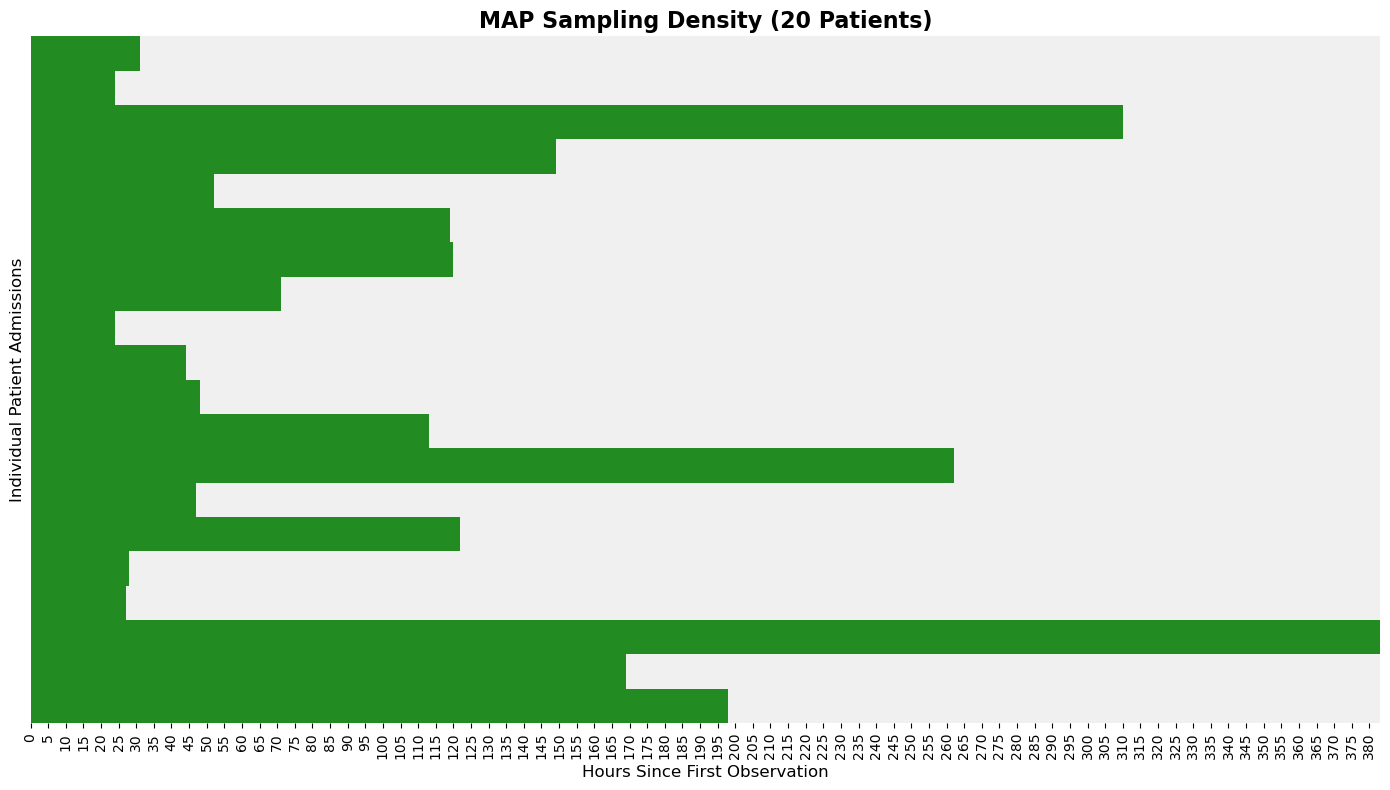

In [137]:
# Replot sampling density to ensure forward fill worked
plot_sampling_density(df_map_static_hourly, column_name='MAP', n_patients=20)

#### Check the correlation of age and gender_female with MAP to ensure that these static features are actually significant

In [138]:
agg_rules_map = {
    'MAP': 'mean',
    'age': 'first', 
    'gender_female': 'first'}

static_corr = df_map_static_hourly.groupby('stay_id').agg(agg_rules_map).corr()
static_corr


,MAP,age,gender_female
MAP,1.000000,-0.306657,-0.021835
age,-0.306657,1.000000,-0.021460
gender_female,-0.021835,-0.021460,1.000000


Result above presents that static features does have an impact on MAP and should be kept

### Feature Engineering: Temporal Exogenous Variables

To enhance the predictive power of the sequence models (LSTM/TFT), we selected a suite of time-varying exogenous variables. These features represent the **"Context of Support"** (e.g., ventilator settings) and the **"Physiological State"** (e.g., vital signs and neurological scores) of the patient. Both categories are critical for forecasting hemodynamic shifts as they capture the body's response to both illness and clinical intervention.

#### Clinical Feature
| Item ID(s) | Feature Name | Feature Category | Clinical Rationale & Relationship to MAP |
| :--- | :--- | :--- | :--- |
| **220045** | Heart Rate (HR) | Hemodynamics | **Inverse/Direct Relationship:** Significant tachycardia (high HR) reduces diastolic filling time, which can decrease stroke volume and drop MAP. Conversely, bradycardia (low HR) can directly lower cardiac output. |
| **220210** | Respiratory Rate | Respiration | **Autonomic Signal:** Rapid breathing (tachypnea) is a common compensatory response to metabolic acidosis or poor tissue perfusion (hypotension). |
| **220277** | SpO2 | Oxygenation | **Tissue Perfusion:** Low oxygen saturation can trigger systemic compensatory mechanisms (vasoconstriction or vasodilation) to prioritize oxygen delivery to vital organs. |
| **220339** | PEEP set | Ventilation | **Intrathoracic Pressure:** High PEEP keeps alveoli open but increases pressure within the chest. This can compress the heart and reduce venous return, often leading to a **decrease in MAP**. |
| **223835** | FiO2 | Ventilation | **Metabolic Context:** The fraction of inspired oxygen reflects the severity of respiratory failure; changes in FiO2 provide the model with context regarding the patient's overall oxygenation demand. |
| **223761** | Temperature | Metabolism | **Vascular Tone:** Fever (hyperthermia) typically causes systemic vasodilation, which can lower MAP, while hypothermia can trigger vasoconstriction to preserve core heat. |
| **227073** | GCS - Total | Neurological | **Consciousness:** A global measure of neurological status. Fluctuations can correlate with changes in cerebral perfusion pressure and overall hemodynamic stability. |
| **223901** | GCS - Motor | Neurological | **Autonomic Compensation:** Low GCS Motor scores often signal cerebral ischemia. In response, the body may trigger a massive sympathetic surge (Cushing Response) to increase systemic MAP, attempting to overcome intracranial resistance and restore cerebral blood flow.

#### Continuous Interventions (Input Events)
These features represent active clinical efforts to manipulate MAP and are essential for the model to distinguish between "natural" recovery and "drug-induced" stability.

| Item ID | Feature Name | Type | Clinical Mechanism |
| :--- | :--- | :--- | :--- |
| **221906** | Norepinephrine | Vasopressor | A potent alpha-1 adrenergic agonist that increases MAP by inducing systemic vasoconstriction. It is the primary treatment for distributive shock. |
| **225158** | NaCl 0.9% | Crystalloid | An isotonic fluid used for volume expansion. Increasing the circulating blood volume (preload) directly increases cardiac output and MAP in fluid-responsive patients. |

In [139]:
# Obtain row with the targetted itemid
chart_features = [220045, 220210, 220277, 223761, 220739, 223901, 223900, 220339, 223835]
chart_features_df = chart_df[chart_df['itemid'].isin(chart_features)]
chart_features_df.head()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
37,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-16 00:02:00,220210,19,19.0,insp/min,0.0
63,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:46:00,223901,Obeys Commands,6.0,NaN,0.0
69,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-16 00:02:00,220045,80,80.0,bpm,0.0
75,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:46:00,220739,To Speech,3.0,NaN,0.0
84,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:46:00,223900,Oriented,5.0,NaN,0.0


In [140]:
# Verifies that UOM is the same for each value, so no need to perform unit standardisation
chart_features_df.groupby('itemid')['valueuom'].value_counts()

itemid  valueuom
220045  bpm         13913
220210  insp/min    13913
220277  %           13540
220339  cmH2O        1447
223761  °F           3379
Name: count, dtype: int64

In [141]:
# 1. Convert charttime to proper datetime objects
chart_features_df['charttime'] = pd.to_datetime(chart_features_df['charttime'])

# 2. Pivot the table
df_chart_features_pivotted = pd.pivot_table(
    chart_features_df,
    index=['subject_id', 'hadm_id', 'stay_id', 'caregiver_id', 'charttime'],
    columns='itemid',
    values='valuenum',  
    aggfunc='first' 
)

# 3. Clean up the axis name (optional, but removes the floating 'itemid' label over the index)
df_chart_features_pivotted.columns.name = None

# 4. Flatten the index
df_chart_features_pivotted.reset_index(inplace=True)

# 5. Rename the columns according to item_id
df_chart_features_pivotted.rename(columns=id_to_label, inplace=True)

# 6. Create the total GCS feature and drop eye opening and verbal as it is deemed less important
df_chart_features_pivotted['GCS'] = df_chart_features_pivotted['GCS - Eye Opening'] + df_chart_features_pivotted['GCS - Motor Response'] + df_chart_features_pivotted['GCS - Verbal Response']
df_chart_features_pivotted.drop(columns=['GCS - Eye Opening', 'GCS - Verbal Response'], inplace=True)
df_chart_features_pivotted.head()

/var/folders/5n/m32d0hsx4959r42x3mssyjj40000gn/T/ipykernel_81718/1447976826.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chart_features_df['charttime'] = pd.to_datetime(chart_features_df['charttime'])


,subject_id,hadm_id,stay_id,caregiver_id,charttime,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,PEEP set,Temperature Fahrenheit,Inspired O2 Fraction,GCS - Motor Response,GCS
0,10000032,29079034,39553978,47007.0,2180-07-23 22:00:00,94.0,20.0,95.0,NaN,NaN,NaN,NaN,NaN
1,10000032,29079034,39553978,66056.0,2180-07-23 19:00:00,97.0,16.0,98.0,NaN,NaN,NaN,NaN,NaN
2,10000032,29079034,39553978,66056.0,2180-07-23 20:00:00,100.0,19.0,99.0,NaN,99.5,NaN,6.0,15.0
3,10000032,29079034,39553978,66056.0,2180-07-23 21:00:00,94.0,22.0,95.0,NaN,NaN,NaN,NaN,NaN
4,10000032,29079034,39553978,88981.0,2180-07-23 14:00:00,NaN,NaN,NaN,NaN,98.7,NaN,NaN,NaN


In [142]:
# Performing Aggregation to hourly level, using different method for each features depending on their property
agg_rules = {
    'Heart Rate': 'mean',
    'Respiratory Rate': 'mean',
    'O2 saturation pulseoxymetry': 'mean',
    'Temperature Fahrenheit': 'mean',
    'PEEP set': 'mean',
    'Inspired O2 Fraction': 'mean',
    'GCS': 'max',
    'GCS - Motor Response': 'max' 
}

df_chart_features_hourly = df_chart_features_pivotted.groupby(['subject_id', 'hadm_id','stay_id']).resample('1h', on='charttime').agg(agg_rules).reset_index()
df_chart_features_hourly.drop(columns=['subject_id', 'hadm_id', 'charttime', 'stay_id']).describe()

,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,Temperature Fahrenheit,PEEP set,Inspired O2 Fraction,GCS,GCS - Motor Response
count,12033.000000,12027.000000,11838.000000,3293.000000,1401.000000,1693.000000,3232.000000,3239.000000
mean,90.750365,20.017178,96.746817,98.593419,6.761123,46.990549,11.557240,5.260574
std,18.328295,5.459268,2.852805,1.068941,3.102917,16.559243,3.745106,1.443829
min,0.000000,0.000000,29.000000,94.000000,0.000000,0.000000,3.000000,1.000000
25%,78.000000,16.000000,95.000000,98.000000,5.000000,40.000000,9.000000,5.000000
50%,90.000000,20.000000,97.000000,98.400000,5.000000,40.000000,13.000000,6.000000
75%,103.000000,23.000000,99.000000,99.000000,8.000000,50.000000,15.000000,6.000000
max,163.000000,58.000000,100.000000,103.400000,16.000000,100.000000,15.000000,6.000000


#### Now we must handle outlier for features, this will be handles based on plausible values
These outlier values are obtained from literature [[2](#Ref2)]

In [143]:
# Apply thresholds from literature for high-fidelity signal filtering
thresholds = {
    'Heart Rate': (10, 400), # 10 captures profound bradycardia but removes lead-off noise
    'Respiratory Rate': (1, 100),
    'O2 saturation pulseoxymetry': (10, 100), # 10% used as the absolute physiological floor
    'Inspired O2 Fraction': (21, 100) # Minimum 21% (Room Air)
}

for col, (low, high) in thresholds.items():
    if col in df_chart_features_hourly.columns:
        df_chart_features_hourly.loc[(df_chart_features_hourly[col] < low) | (df_chart_features_hourly[col] > high), col] = np.nan

df_chart_features_hourly.drop(columns=['subject_id', 'hadm_id', 'charttime', 'stay_id']).describe()

,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,Temperature Fahrenheit,PEEP set,Inspired O2 Fraction,GCS,GCS - Motor Response
count,12032.000000,12005.000000,11838.000000,3293.000000,1401.000000,1690.000000,3232.000000,3239.000000
mean,90.757908,20.053861,96.746817,98.593419,6.761123,47.069231,11.557240,5.260574
std,18.310372,5.396530,2.852805,1.068941,3.102917,16.467955,3.745106,1.443829
min,21.250000,3.000000,29.000000,94.000000,0.000000,21.000000,3.000000,1.000000
25%,78.000000,16.000000,95.000000,98.000000,5.000000,40.000000,9.000000,5.000000
50%,90.000000,20.000000,97.000000,98.400000,5.000000,40.000000,13.000000,6.000000
75%,103.000000,23.000000,99.000000,99.000000,8.000000,50.000000,15.000000,6.000000
max,163.000000,58.000000,100.000000,103.400000,16.000000,100.000000,15.000000,6.000000


In [144]:
# non null proportion (reminder that each value is hourly)
(len(df_chart_features_hourly) - df_chart_features_hourly.isna().sum())/len(df_chart_features_hourly)

subject_id                     1.000000
hadm_id                        1.000000
stay_id                        1.000000
charttime                      1.000000
Heart Rate                     0.974646
Respiratory Rate               0.972458
O2 saturation pulseoxymetry    0.958931
Temperature Fahrenheit         0.266748
PEEP set                       0.113487
Inspired O2 Fraction           0.136898
GCS                            0.261806
GCS - Motor Response           0.262373
dtype: float64

### Tiered Forward-Fill Strategy for each feature

By analysing the frequency of data entries within the records, we can identify the standard monitoring intervals used in the ICU. The analysis above shows that vitals like **Heart Rate, Respiratory Rate, and SpO2** are checked almost every hour. In contrast, **Temperature and GCS** (coma scale) usually happen every 4 hours (non null proportion = ~0.25), while ventilator settings like **PEEP and FiO2** are updated roughly every 8 hours, likely matching respiratory therapy shifts.

To fill these gaps without making up unrealistic data, we use a "Last Observation Carried Forward" (LOCF) strategy with limits based on how fast each value actually changes:

* **Vital Signs (1-hour limit):** We only carry these forward for one hour. This keeps the data "fresh" so the model doesn't rely on old information when a patient's condition might be shifting quickly.
* **Routine Assessments (4-hour limit):** This follows the standard "Q4" nursing protocol. It keeps the model aware of the patient’s general status between check-ins without assuming they’ve stayed the same for too long.
* **Device Settings (12-hour limit):** Ventilator settings usually stay exactly where they are until a clinician manually changes them. Because of this stability, a 12-hour window is a safe way to represent the patient’s treatment environment.

In [145]:
# 1. Define feature groups and their respective 'stale' limits

ffill_limits = {
    'normal': {
        'cols': ['Heart Rate', 'Respiratory Rate', 'O2 saturation pulseoxymetry'],
        'limit': 1 # Standard window for hourly vitals 
    },
    'assessment': {
        'cols': ['Temperature Fahrenheit', 'GCS', 'GCS - Motor Response'],
        'limit': 4 # Aligns with the 4-hour clinical assessment window
    },
    'ventilator': {
        'cols': ['PEEP set', 'Inspired O2 Fraction'],
        'limit': 12 # Extended leeway for machine settings
    }
}

# 2. Apply the logic per stay_id, sort first to ensure it ffill is performed correctly
df_chart_features_hourly_ffill = df_chart_features_hourly.sort_values(['stay_id', 'charttime'])

for group in ffill_limits.values():
    cols = group['cols']
    limit = group['limit']
    
    # Apply ffill only to the specific columns with the specific limit
    df_chart_features_hourly_ffill[cols] = (
        df_chart_features_hourly_ffill.groupby('stay_id')[cols]
        .ffill(limit=limit)
    )

# 3. Final verification
print(df_chart_features_hourly_ffill.isnull().sum())
df_chart_features_hourly_ffill.head()

subject_id                        0
hadm_id                           0
stay_id                           0
charttime                         0
Heart Rate                      174
Respiratory Rate                169
O2 saturation pulseoxymetry     268
Temperature Fahrenheit         1091
PEEP set                       6899
Inspired O2 Fraction           5849
GCS                            1766
GCS - Motor Response           1748
dtype: int64


,subject_id,hadm_id,stay_id,charttime,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,Temperature Fahrenheit,PEEP set,Inspired O2 Fraction,GCS,GCS - Motor Response
8871,10023117,28872262,30057454,2171-11-14 10:00:00,108.750000,18.0,93.250000,98.6,NaN,NaN,NaN,NaN
8872,10023117,28872262,30057454,2171-11-14 11:00:00,102.333333,20.0,94.666667,97.9,NaN,NaN,15.0,6.0
8873,10023117,28872262,30057454,2171-11-14 12:00:00,103.000000,21.0,91.000000,97.9,NaN,NaN,15.0,6.0
8874,10023117,28872262,30057454,2171-11-14 13:00:00,108.000000,23.0,95.000000,97.9,NaN,NaN,15.0,6.0
8875,10023117,28872262,30057454,2171-11-14 14:00:00,105.000000,18.0,94.000000,97.9,NaN,NaN,15.0,6.0


In [146]:
# Merge the table together with the MAP table
df_map_features = df_map_static_hourly.merge(
    df_chart_features_hourly_ffill,
    on=['subject_id', 'hadm_id', 'stay_id', 'charttime'],
    how='left'
)
df_map_features.head()

,subject_id,hadm_id,stay_id,charttime,MAP,age,gender_female,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,Temperature Fahrenheit,PEEP set,Inspired O2 Fraction,GCS,GCS - Motor Response
0,10001217,24597018,37067082,2157-11-20 19:00:00,104.0,55.0,1.0,86.0,18.0,99.0,98.5,NaN,NaN,15.0,6.0
1,10001217,24597018,37067082,2157-11-20 20:00:00,95.0,55.0,1.0,91.0,24.0,98.0,98.5,NaN,NaN,15.0,6.0
2,10001217,24597018,37067082,2157-11-20 21:00:00,103.0,55.0,1.0,95.0,25.0,98.0,98.5,NaN,NaN,15.0,6.0
3,10001217,24597018,37067082,2157-11-20 22:00:00,93.0,55.0,1.0,102.0,27.0,95.0,99.1,NaN,NaN,15.0,6.0
4,10001217,24597018,37067082,2157-11-20 23:00:00,88.0,55.0,1.0,106.0,20.0,98.0,99.1,NaN,NaN,15.0,6.0


In [147]:
df_map_features.isna().sum()

subject_id                        0
hadm_id                           0
stay_id                           0
charttime                         0
MAP                               0
age                               0
gender_female                     0
Heart Rate                       92
Respiratory Rate                109
O2 saturation pulseoxymetry     171
Temperature Fahrenheit          984
PEEP set                       6679
Inspired O2 Fraction           5620
GCS                            1673
GCS - Motor Response           1660
dtype: int64

#### Final Imputation to fill all missing values

In [148]:
# Define the logical medical defaults and statistical medians, note that these value are from df df_chart_features_hourly, meaning before ffill occurs
final_imputation_values = {
    'Heart Rate': df_chart_features_hourly['Heart Rate'].median(),
    'Respiratory Rate': df_chart_features_hourly['Respiratory Rate'].median(),
    'O2 saturation pulseoxymetry': df_chart_features_hourly['O2 saturation pulseoxymetry'].median(),
    'GCS': df_chart_features_hourly['GCS'].median(),
    'GCS - Motor Response': df_chart_features_hourly['GCS - Motor Response'].median(),
    'Temperature Fahrenheit': 98.6,
    'Inspired O2 Fraction': 21,
    'PEEP set': 0
}

# Apply the final fills
df_map_features = df_map_features.fillna(value=final_imputation_values)

# Final check to ensure 0 NaNs remain
df_map_features.isnull().sum()

subject_id                     0
hadm_id                        0
stay_id                        0
charttime                      0
MAP                            0
age                            0
gender_female                  0
Heart Rate                     0
Respiratory Rate               0
O2 saturation pulseoxymetry    0
Temperature Fahrenheit         0
PEEP set                       0
Inspired O2 Fraction           0
GCS                            0
GCS - Motor Response           0
dtype: int64

#### Preprocessing input features

In [149]:
## The input features is in a different table with some difference in formatting, so there will be some difference in cleaning the table up
df_input = pd.read_csv(f'{mimic_path}/icu/inputevents.csv')
df_input = df_input[df_input['itemid'].isin([221906, 225158])]
df_input.sort_values(by=['subject_id','starttime'], ascending=[True, True])

,subject_id,hadm_id,stay_id,caregiver_id,starttime,endtime,storetime,itemid,amount,amountuom,...,ordercomponenttypedescription,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate
5921,10001217,24597018,37067082,84976,2157-11-20 19:32:00,2157-11-21 08:49:00,2157-11-21 08:48:00,225158,1000.000037,ml,...,Main order parameter,Continuous IV,71.2,1000.0,ml,0,0,FinishedRunning,1000.000000,75.282310
5919,10001217,24597018,37067082,84976,2157-11-21 00:21:00,2157-11-21 00:22:00,2157-11-21 02:21:00,225158,100.000000,ml,...,Mixed solution,Drug Push,71.2,100.0,ml,0,0,FinishedRunning,100.000000,0.000000
5920,10001217,24597018,37067082,72136,2157-11-21 08:49:00,2157-11-21 09:15:00,2157-11-21 08:48:00,225158,32.500000,ml,...,Main order parameter,Continuous IV,71.2,1000.0,ml,0,0,ChangeDose/Rate,1000.000000,75.000000
5916,10001217,24597018,37067082,72136,2157-11-21 09:12:00,2157-11-21 09:13:00,2157-11-21 17:16:00,225158,250.000000,ml,...,Mixed solution,Drug Push,71.2,250.0,ml,0,0,FinishedRunning,250.000000,0.000000
5918,10001217,24597018,37067082,72136,2157-11-21 09:15:00,2157-11-21 12:12:00,2157-11-21 09:13:00,225158,14.750000,ml,...,Main order parameter,Continuous IV,71.2,1000.0,ml,0,0,Stopped,967.500000,5.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9279,10040025,27996267,36107367,72136,2148-01-28 13:36:00,2148-01-28 13:42:00,2148-01-28 13:36:00,225158,1.939237,ml,...,Mixed solution,Continuous Med,77.4,100.0,ml,0,0,Stopped,83.710403,19.392357
9263,10040025,27996267,36107367,82148,2148-01-28 14:00:00,2148-01-30 16:00:00,2148-01-28 15:25:00,225158,500.000015,ml,...,Main order parameter,Continuous IV,77.4,500.0,ml,0,0,FinishedRunning,500.000000,10.000000
9293,10040025,27996267,36107367,59423,2148-01-29 20:00:00,2148-01-29 20:01:00,2148-01-29 22:49:00,225158,100.000000,ml,...,Mixed solution,Drug Push,77.4,100.0,ml,0,0,FinishedRunning,100.000000,0.000000
9283,10040025,27996267,36107367,27035,2148-01-30 08:03:00,2148-01-30 08:04:00,2148-01-30 08:03:00,225158,100.000000,ml,...,Mixed solution,Drug Push,77.4,100.0,ml,0,0,FinishedRunning,100.000000,0.000000


In [150]:
# Ensures that for each measurement there is only one unit of measurement so no need to standardise them
df_input.groupby('itemid')['amountuom'].value_counts()

itemid  amountuom
221906  mg            947
225158  ml           2870
Name: count, dtype: int64

In [151]:
# 1. Convert charttime to proper datetime objects
df_input['starttime'] = pd.to_datetime(df_input['starttime'])
df_input['endtime'] = pd.to_datetime(df_input['endtime'])

# 2. Pivot the table
df_input_pivotted = pd.pivot_table(
    df_input,
    index=['subject_id', 'hadm_id', 'stay_id', 'caregiver_id', 'starttime', 'endtime'],
    columns='itemid',
    values='amount',  
    aggfunc='first' 
)

# 3. Clean up the axis name (optional, but removes the floating 'itemid' label over the index)
df_input_pivotted.columns.name = None

# 4. Flatten the index
df_input_pivotted.reset_index(inplace=True)
# 5. Rename the columns according to item_id
df_input_pivotted.rename(columns=id_to_label, inplace=True)

df_input_pivotted[['Norepinephrine', 'NaCl 0.9%']].describe()

,Norepinephrine,NaCl 0.9%
count,947.000000,2860.000000
mean,1.246152,128.890308
std,1.746376,230.998714
min,0.004195,0.008334
25%,0.201956,9.027501
50%,0.620357,49.999999
75%,1.525673,100.000000
max,16.000001,2000.000000


To synchronize pharmacological interventions with hourly vitals, we transform the starttime and endttime column into the charttime column by performing the following:

* **Temporal Proportionality:** We calculate the exact duration (in minutes) a drug was active within each 60-minute window, accounting for administrations that do not start or end on the hour.
* **Proportional Allocation:** The total dose is distributed across hourly bins based on time overlap. For instance, an injection spanning 1:45 PM to 2:15 PM is split proportionally between the 1:00 PM and 2:00 PM hours.
* **Zero-Infill Imputation:** After merging with the master hourly grid, all missing values are filled with **0**. This explicitly represents periods without medication, allowing the model to distinguish between active treatment and baseline physiological states.

In [152]:
# Need to now align the data point to hourly and convert the name to charttime to align with other tables, this 
# also involve separating calculations by the hour as well looking at starttime and endttime

def align_pivoted_inputs(df_pivoted, df_grid, feature_cols):
    """
    df_pivoted: Pivoted table with 'starttime', 'endtime', and feature columns.
    df_grid:  1-hour grid (stay_id, charttime) from the features and map table
    feature_cols: Feature list (['Norepinephrine', 'NaCl 0.9%'])
    """
    expanded_rows = []

    for _, row in df_pivoted.iterrows():
        # Calculate total duration in minutes to determine the 'rate'
        duration_mins = (row['endtime'] - row['starttime']).total_seconds() / 60
        if duration_mins <= 0: duration_mins = 1 # Handle instantaneous events
        
        # Determine the range of hours this window covers
        start_hour = row['starttime'].floor('h')
        end_hour = row['endtime'].floor('h')
        hour_range = pd.date_range(start=start_hour, end=end_hour, freq='h')

        for hr in hour_range:
            # Calculate the specific overlap for THIS hour
            bucket_start = hr
            bucket_end = hr + pd.Timedelta(hours=1)
            
            overlap_start = max(row['starttime'], bucket_start)
            overlap_end = min(row['endtime'], bucket_end)
            
            if overlap_end > overlap_start:
                overlap_mins = (overlap_end - overlap_start).total_seconds() / 60
                proportion = overlap_mins / duration_mins
                
                # Store the allocated portion for each feature
                entry = {'stay_id': row['stay_id'], 'charttime': hr}
                for col in feature_cols:
                    if pd.notnull(row[col]):
                        entry[col] = row[col] * proportion
                expanded_rows.append(entry)

    # 2. Combine and sum all partial allocations that land in the same hour
    df_expanded = pd.DataFrame(expanded_rows)
    df_hourly = df_expanded.groupby(['stay_id', 'charttime']).sum().reset_index()

    # 3. Final merge with your main grid
    df_final = pd.merge(df_grid, df_hourly, on=['stay_id', 'charttime'], how='left')
    df_final[feature_cols] = df_final[feature_cols].fillna(0)
    
    return df_final


In [153]:
df_grid = df_map_features[['stay_id', 'charttime']].copy().drop_duplicates()
feature_cols = ['Norepinephrine', 'NaCl 0.9%']
df_input_aligned = align_pivoted_inputs(df_input_pivotted, df_grid, feature_cols)
df_input_aligned

,stay_id,charttime,NaCl 0.9%,Norepinephrine
0,37067082,2157-11-20 19:00:00,35.131745,0.0
1,37067082,2157-11-20 20:00:00,75.282311,0.0
2,37067082,2157-11-20 21:00:00,75.282311,0.0
3,37067082,2157-11-20 22:00:00,75.282311,0.0
4,37067082,2157-11-20 23:00:00,75.282311,0.0
...,...,...,...,...
12069,36107367,2148-01-30 12:00:00,110.000000,0.0
12070,36107367,2148-01-30 13:00:00,10.000000,0.0
12071,36107367,2148-01-30 14:00:00,10.000000,0.0
12072,36107367,2148-01-30 15:00:00,10.000000,0.0


#### Merge the final input together

In [154]:
df_map_with_input = pd.merge(df_map_features, df_input_aligned, on=['stay_id', 'charttime'], how='left')
df_map_with_input

,subject_id,hadm_id,stay_id,charttime,MAP,age,gender_female,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,Temperature Fahrenheit,PEEP set,Inspired O2 Fraction,GCS,GCS - Motor Response,NaCl 0.9%,Norepinephrine
0,10001217,24597018,37067082,2157-11-20 19:00:00,104.0,55.0,1.0,86.0,18.0,99.0,98.5,0.0,21.0,15.0,6.0,35.131745,0.0
1,10001217,24597018,37067082,2157-11-20 20:00:00,95.0,55.0,1.0,91.0,24.0,98.0,98.5,0.0,21.0,15.0,6.0,75.282311,0.0
2,10001217,24597018,37067082,2157-11-20 21:00:00,103.0,55.0,1.0,95.0,25.0,98.0,98.5,0.0,21.0,15.0,6.0,75.282311,0.0
3,10001217,24597018,37067082,2157-11-20 22:00:00,93.0,55.0,1.0,102.0,27.0,95.0,99.1,0.0,21.0,15.0,6.0,75.282311,0.0
4,10001217,24597018,37067082,2157-11-20 23:00:00,88.0,55.0,1.0,106.0,20.0,98.0,99.1,0.0,21.0,15.0,6.0,75.282311,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12069,10040025,27996267,36107367,2148-01-30 12:00:00,86.0,69.0,1.0,85.0,23.0,93.0,97.5,0.0,21.0,14.0,6.0,110.000000,0.0
12070,10040025,27996267,36107367,2148-01-30 13:00:00,85.0,69.0,1.0,81.0,15.0,94.0,97.5,0.0,21.0,13.0,6.0,10.000000,0.0
12071,10040025,27996267,36107367,2148-01-30 14:00:00,96.0,69.0,1.0,71.0,15.0,95.0,97.5,0.0,21.0,13.0,6.0,10.000000,0.0
12072,10040025,27996267,36107367,2148-01-30 15:00:00,80.0,69.0,1.0,83.0,14.0,96.0,97.4,0.0,21.0,13.0,6.0,10.000000,0.0


In [155]:
# Dropped unused columns (subject_id info is already used with the respective age and gender_female column)
df_map_with_input.drop(columns=['subject_id', 'hadm_id'], inplace=True)
df_map_with_input

,stay_id,charttime,MAP,age,gender_female,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,Temperature Fahrenheit,PEEP set,Inspired O2 Fraction,GCS,GCS - Motor Response,NaCl 0.9%,Norepinephrine
0,37067082,2157-11-20 19:00:00,104.0,55.0,1.0,86.0,18.0,99.0,98.5,0.0,21.0,15.0,6.0,35.131745,0.0
1,37067082,2157-11-20 20:00:00,95.0,55.0,1.0,91.0,24.0,98.0,98.5,0.0,21.0,15.0,6.0,75.282311,0.0
2,37067082,2157-11-20 21:00:00,103.0,55.0,1.0,95.0,25.0,98.0,98.5,0.0,21.0,15.0,6.0,75.282311,0.0
3,37067082,2157-11-20 22:00:00,93.0,55.0,1.0,102.0,27.0,95.0,99.1,0.0,21.0,15.0,6.0,75.282311,0.0
4,37067082,2157-11-20 23:00:00,88.0,55.0,1.0,106.0,20.0,98.0,99.1,0.0,21.0,15.0,6.0,75.282311,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12069,36107367,2148-01-30 12:00:00,86.0,69.0,1.0,85.0,23.0,93.0,97.5,0.0,21.0,14.0,6.0,110.000000,0.0
12070,36107367,2148-01-30 13:00:00,85.0,69.0,1.0,81.0,15.0,94.0,97.5,0.0,21.0,13.0,6.0,10.000000,0.0
12071,36107367,2148-01-30 14:00:00,96.0,69.0,1.0,71.0,15.0,95.0,97.5,0.0,21.0,13.0,6.0,10.000000,0.0
12072,36107367,2148-01-30 15:00:00,80.0,69.0,1.0,83.0,14.0,96.0,97.4,0.0,21.0,13.0,6.0,10.000000,0.0


In [156]:
df_map_with_input.isna().sum()

stay_id                        0
charttime                      0
MAP                            0
age                            0
gender_female                  0
Heart Rate                     0
Respiratory Rate               0
O2 saturation pulseoxymetry    0
Temperature Fahrenheit         0
PEEP set                       0
Inspired O2 Fraction           0
GCS                            0
GCS - Motor Response           0
NaCl 0.9%                      0
Norepinephrine                 0
dtype: int64

In [157]:
df_final_with_input = df_map_with_input.copy()

In [158]:
df_final_with_input.to_csv('data/map-forecast/dataframe/cleaned_map_with_features.csv', index=False)

### Cross Correlation Plot


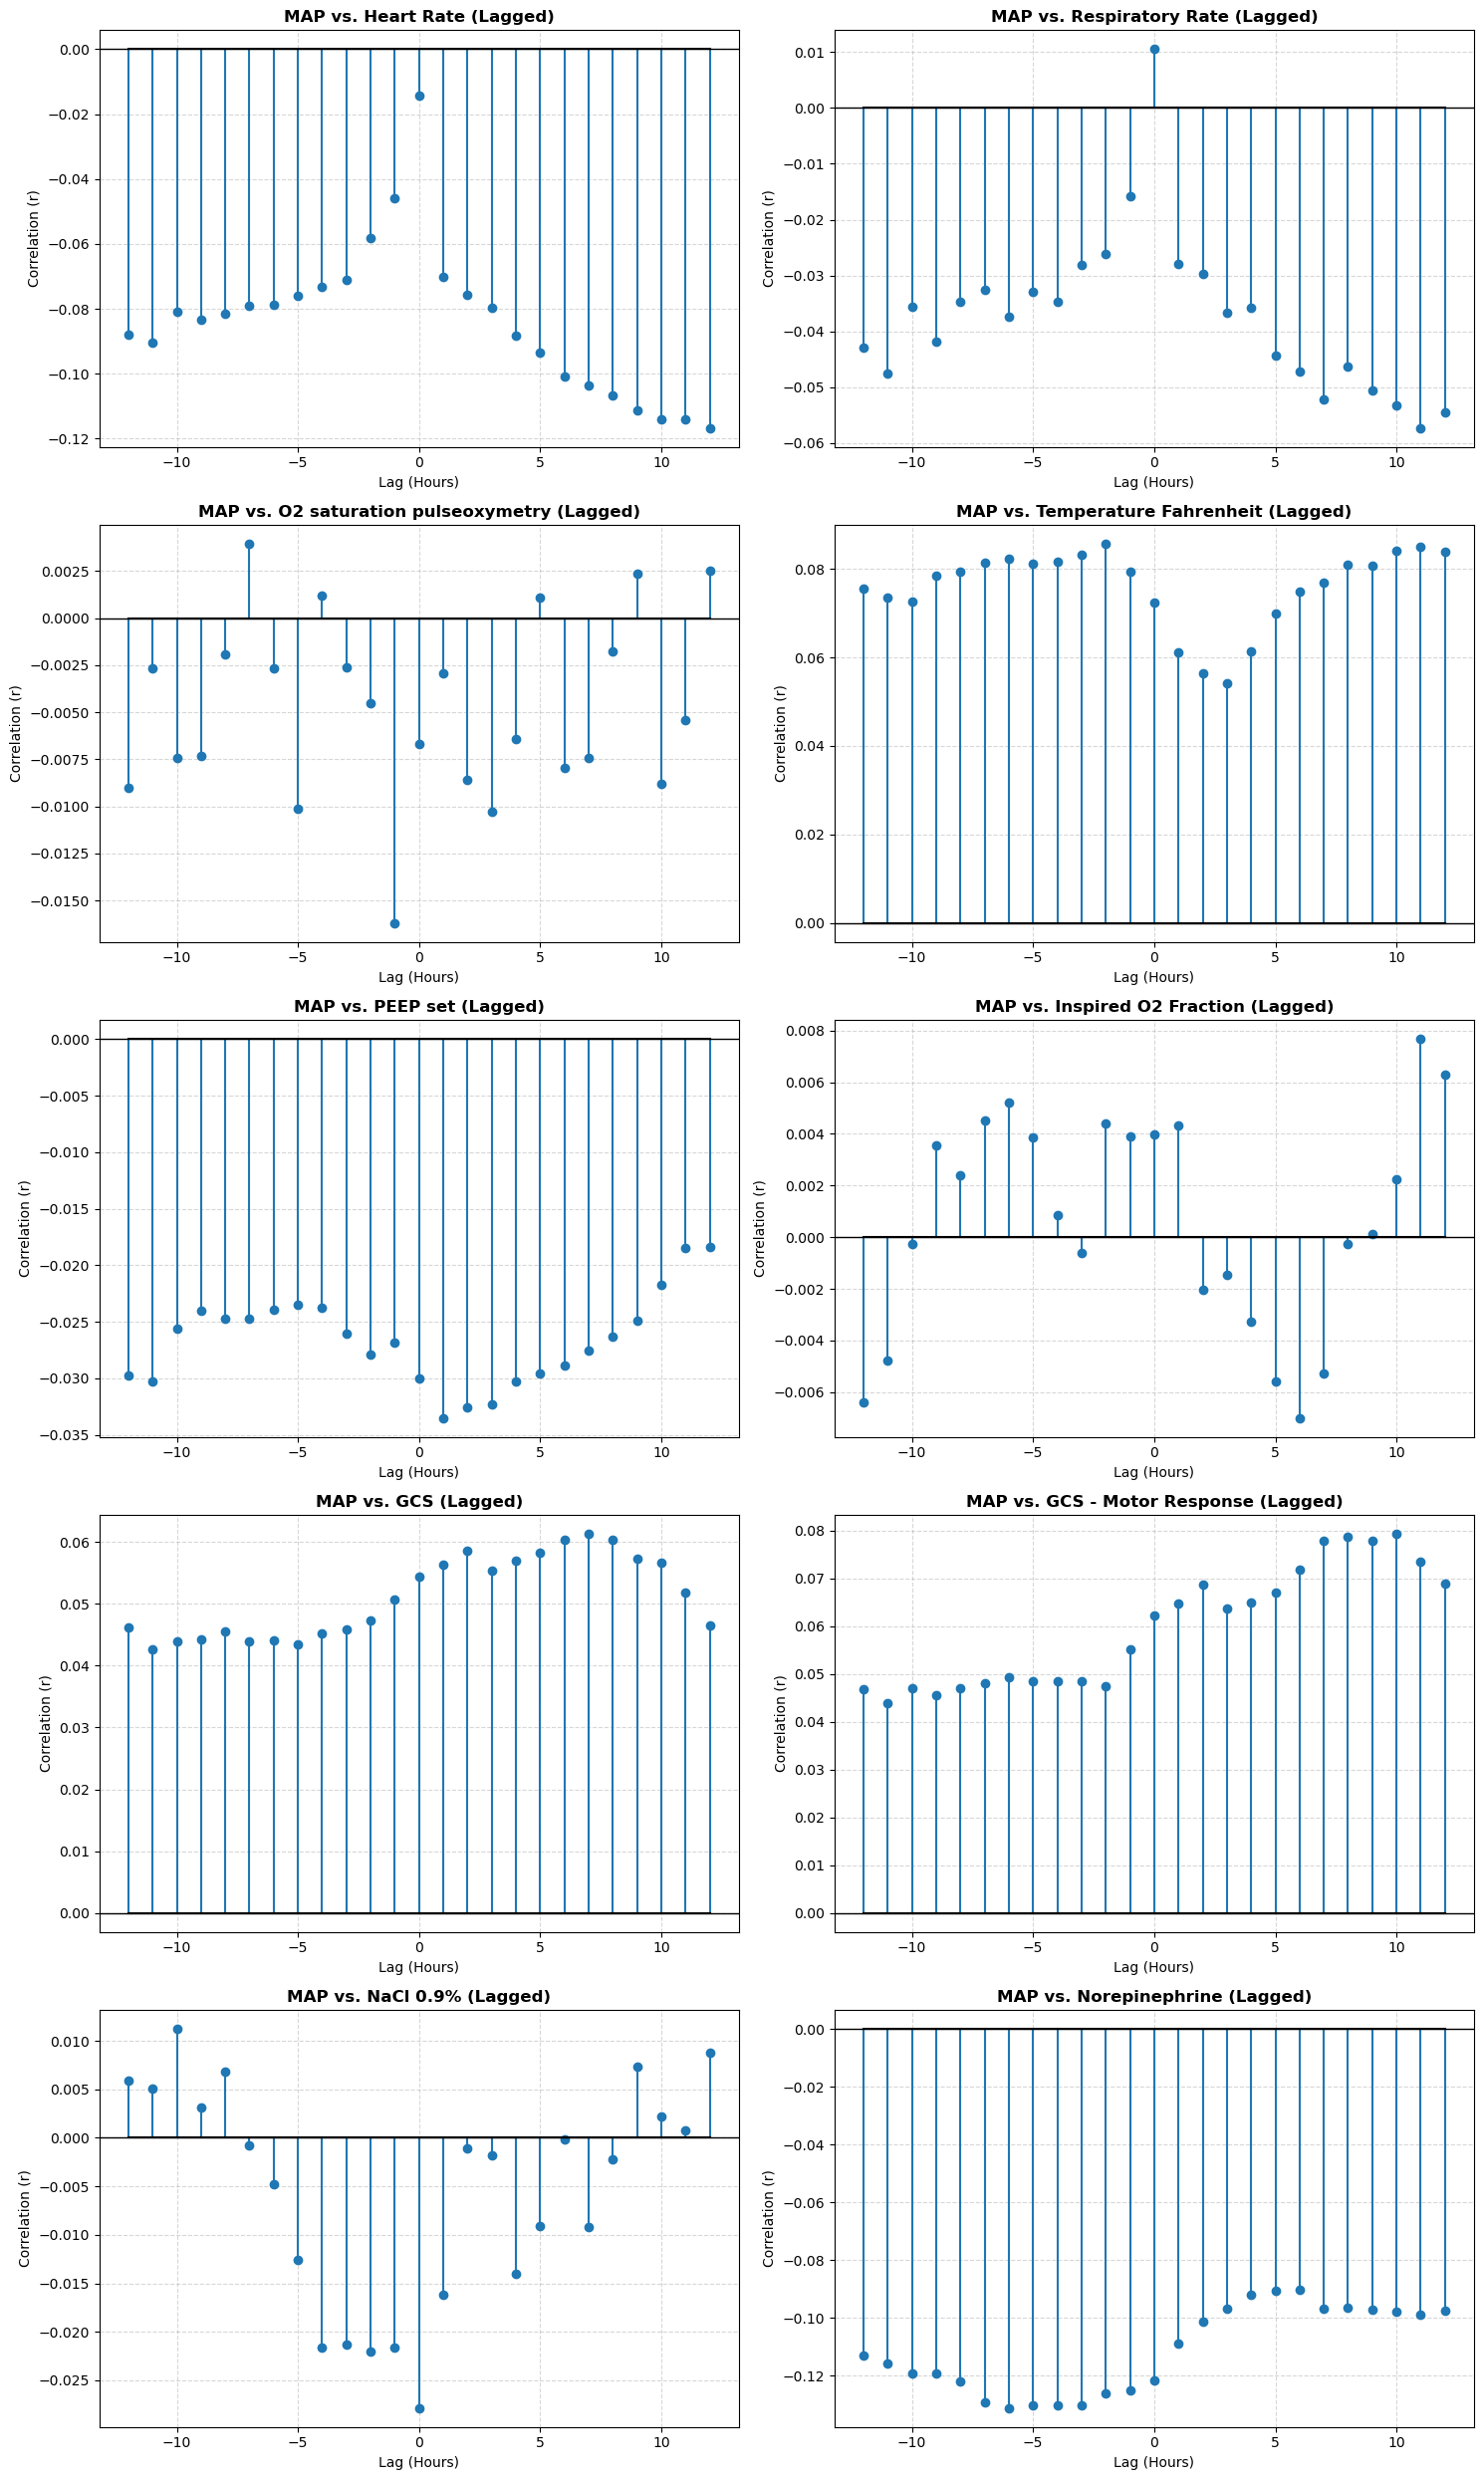

In [159]:
# Updated feature list (Total of 8 features)
features_to_plot = [
    'Heart Rate', 'Respiratory Rate', 'O2 saturation pulseoxymetry', 
    'Temperature Fahrenheit', 'PEEP set', 'Inspired O2 Fraction', 
    'GCS', 'GCS - Motor Response', 'NaCl 0.9%', 'Norepinephrine'
]

max_lag = 12
n_features = len(features_to_plot)
cols = 2
rows = (n_features + 1) // cols  # Dynamically calculate required rows

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15, rows * 5))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    # Standardize data for cross-correlation [cite: 85, 95]
    y = (df_final_with_input['MAP'] - df_final_with_input['MAP'].mean()) / df_final_with_input['MAP'].std()
    x = (df_final_with_input[feature] - df_final_with_input[feature].mean()) / df_final_with_input[feature].std()
    
    lags = np.arange(-max_lag, max_lag + 1)
    corrs = [y.corr(x.shift(lag)) for lag in lags]
    
    ax = axes[i]
    ax.stem(lags, corrs, basefmt="k-")
    ax.set_title(f'MAP vs. {feature} (Lagged)', fontweight='bold')
    ax.set_xlabel('Lag (Hours)')
    ax.set_ylabel('Correlation (r)')
    ax.axhline(0, color='black', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.5)

# Only delete subplots if there are more axes than features 
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Observations for the Cross Correlation Plot

The cross-correlation analysis between MAP and exogenous features reveals distinct temporal patterns that are critical for guiding the feature selection process for our sequence models:

* **Strongest Predictive Signals:**
    * **Norepinephrine ($r \approx -0.13$):** This feature demonstrates the strongest correlation. The pronounced negative correlation at lag 0 and negative lags reflects "Reactive Intervention"—clinicians increase vasopressor dosage in response to declining MAP. This is a vital "contextual" feature for the model to distinguish between clinical deterioration and drug-induced recovery.
    * **Heart Rate ($r \approx -0.12$):** Confirms a strong inverse relationship. The peak correlation at lag 0 suggests that as tachycardia increases (likely due to compensatory mechanisms or decreased diastolic filling), MAP simultaneously decreases.

* **GCS Score (Motor vs. Total):**
    * **Signal Quality:** **GCS - Motor ($r \approx 0.08$)** outperforms **GCS - Total ($r \approx 0.06$)**. In the ICU, the Total score is often confounded by sedation or intubation; the Motor component provides a "purer" signal of neurological status relative to blood pressure regulation.
    * **Ischemic Response:** Low motor scores often indicate **cerebral ischemia**. This can trigger a sympathetic surge to increase systemic MAP, an autonomic attempt to overcome intracranial resistance and restore cerebral blood flow.

* **Ventilatory & Metabolic Influence:**
    * **PEEP set ($r \approx -0.035$):** Shows a sustained negative correlation, validating the physiological theory that increased intrathoracic pressure reduces venous return, subsequently lowering MAP.
    * **Temperature Fahrenheit ($r \approx 0.08$):** While fever typically induces vasodilation (which lowers MAP), this positive association suggests a more complex relationship, potentially reflecting compensatory sympathetic surges or the concurrent use of vasopressors during febrile episodes.

* **Intervention Dynamics (NaCl 0.9%):**
    * The correlation for **NaCl 0.9%** dips significantly around Lag 0, reflecting the acute clinical response where a fluid bolus is administered immediately following a detected drop in blood pressure.

* **Low-Signal Features (Candidate for Pruning):**
    * **SpO2 and Inspired O2 Fraction (FiO2)** both exhibit negligible correlation ($|r| < 0.01$). While clinically essential for respiratory monitoring, their linear relationship with MAP is weak in this dataset, suggesting they may contribute more noise than predictive signal for the specific task of MAP forecasting.



This presents that GCS - Motor contains stronger correlation than GCS - Total and since they are highly correlated, I will drop GCS - Total. 

#### Check for correlation between features to potentially prevent multicolinearity

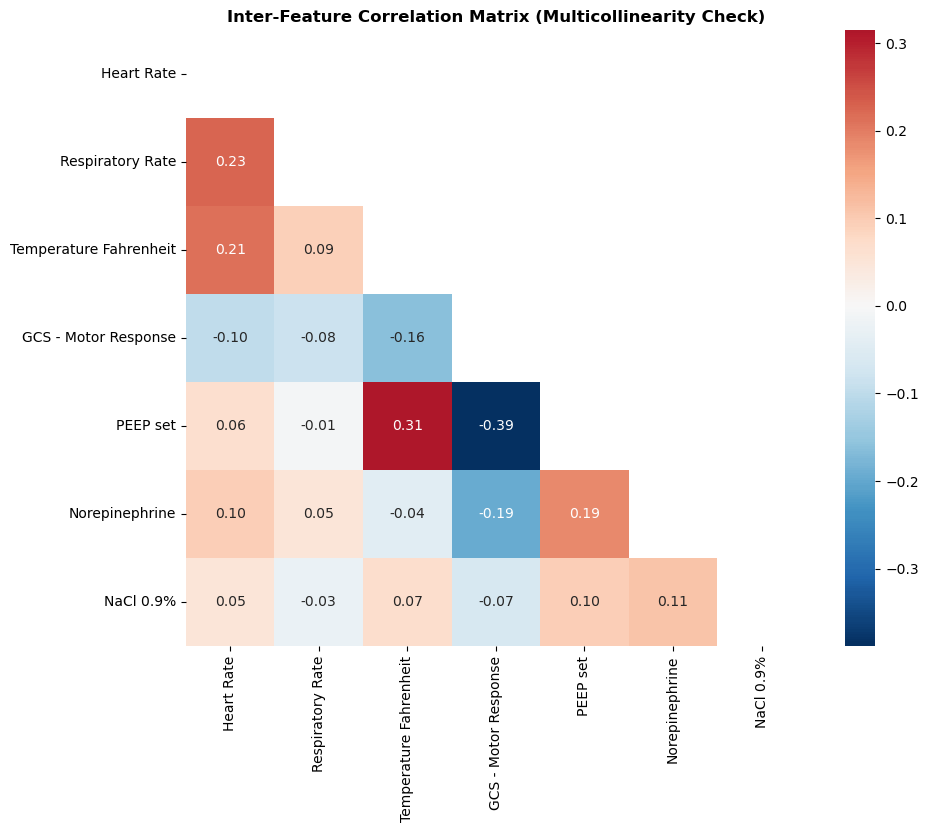

In [160]:
# Select only your finalized exogenous features
features_to_check = [
'Heart Rate', 'Respiratory Rate', 'Temperature Fahrenheit', 
    'GCS - Motor Response', 'PEEP set', 'Norepinephrine', 'NaCl 0.9%'
]

plt.figure(figsize=(10, 8))
corr_matrix = df_final_with_input[features_to_check].corr()

# Create a mask to hide the top half (for a cleaner look)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Inter-Feature Correlation Matrix (Multicollinearity Check)', fontweight='bold')
plt.show()

To ensure model stability, we conducted a multicollinearity check using an inter-feature correlation matrix. All Pearson coefficients remain well below the standard threshold ($|r| < 0.7$), with the strongest association observed between **GCS Motor Response** and **PEEP set** ($r = -0.39$). 

This statistical independence confirms that the selected features provide non-redundant information. For a sequence model like an LSTM or TFT, this lack of high collinearity is critical; it ensures that the model can distinctively attribute weight to specific clinical triggers without the gradients becoming unstable due to redundant inputs.

In [161]:
df_final = df_final_with_input.drop(columns=['GCS', 'Inspired O2 Fraction', 'O2 saturation pulseoxymetry'])
df_final.head()

,stay_id,charttime,MAP,age,gender_female,Heart Rate,Respiratory Rate,Temperature Fahrenheit,PEEP set,GCS - Motor Response,NaCl 0.9%,Norepinephrine
0,37067082,2157-11-20 19:00:00,104.0,55.0,1.0,86.0,18.0,98.5,0.0,6.0,35.131745,0.0
1,37067082,2157-11-20 20:00:00,95.0,55.0,1.0,91.0,24.0,98.5,0.0,6.0,75.282311,0.0
2,37067082,2157-11-20 21:00:00,103.0,55.0,1.0,95.0,25.0,98.5,0.0,6.0,75.282311,0.0
3,37067082,2157-11-20 22:00:00,93.0,55.0,1.0,102.0,27.0,99.1,0.0,6.0,75.282311,0.0
4,37067082,2157-11-20 23:00:00,88.0,55.0,1.0,106.0,20.0,99.1,0.0,6.0,75.282311,0.0


In [162]:
df_final.isna().sum()

stay_id                   0
charttime                 0
MAP                       0
age                       0
gender_female             0
Heart Rate                0
Respiratory Rate          0
Temperature Fahrenheit    0
PEEP set                  0
GCS - Motor Response      0
NaCl 0.9%                 0
Norepinephrine            0
dtype: int64

In [163]:
map_forecast_path = "data/map-forecast"

In [164]:
df_final.to_csv(f'{map_forecast_path}/dataframe/df_map_cleaned_final_selection.csv', index=False)

## Modelling
Each of the model will be run from a separate notebook. This notebook will provide relevant data preprocessing for each invidual model, the relevant hyperparameter tuning (if any) and the results and thier corresponding visualisation. It is also important to note that each of the three model all take slightly different types of input, so the input must be formatted accordingly 

### Data Partitioning & Leakage Prevention

To ensure a robust evaluation, we split the data by stay_id.
* **Methodology:** 20% of unique `stay_id` records were reserved for the hold-out Test Set. This ensures that no data from a specific patient's clinical trajectory exists in both the training and evaluation phases, preventing "Data Leakage."
* **Cross-Model Consistency:** All three models (LSTM, TFT, and Chronos-2) were evaluated on this identical 20% test partition to ensure the validity of the performance comparison.
* **Temporal Windowing**: Each patient’s stay was converted into multiple test cases using a sliding window. For every sample, the model analyzes 12 hours of clinical history (lookback) to forecast the MAP for the next 6 hours (horizon). This approach mimics a real-world clinical setting, where the tool provides continuous, "rolling" early warnings throughout a patient's entire ICU stay. This also provides more data for the model to trained on as the data is already quite limited (100 patients).

In [165]:
# 1. Get unique Stay IDs
unique_stays = df_final['stay_id'].unique()

# 2. Randomly shuffle and split
np.random.seed(42) # Use seed for reproducibility
np.random.shuffle(unique_stays)

train_size = int(len(unique_stays) * 0.8)
train_ids = unique_stays[:train_size]
test_ids = unique_stays[train_size:]

# 3. Create the dataframes
df_train = df_final[df_final['stay_id'].isin(train_ids)]
df_test = df_final[df_final['stay_id'].isin(test_ids)]

print(f"""Training on {len(train_ids)} hospital stays
Testing on {len(test_ids)} hospital stays
""")

Training on 101 hospital stays
Testing on 26 hospital stays



In [166]:
df_train.to_csv(f"{map_forecast_path}/dataframe/df_map_train.csv", index=False)
df_test.to_csv(f"{map_forecast_path}/dataframe/df_map_test.csv", index=False)

In [167]:
df_test = pd.read_csv(f"{map_forecast_path}/dataframe/df_map_test.csv")
df_test

,stay_id,charttime,MAP,age,gender_female,Heart Rate,Respiratory Rate,Temperature Fahrenheit,PEEP set,GCS - Motor Response,NaCl 0.9%,Norepinephrine
0,34592300,2157-12-19 15:00:00,114.0,55.0,1.0,96.0,11.0,98.6,0.0,6.0,0.000000,0.0
1,34592300,2157-12-19 16:00:00,112.0,55.0,1.0,73.0,17.0,97.6,0.0,6.0,0.000000,0.0
2,34592300,2157-12-19 17:00:00,103.0,55.0,1.0,76.5,14.0,97.6,0.0,6.0,128.333333,0.0
3,34592300,2157-12-19 18:00:00,96.0,55.0,1.0,81.0,14.0,97.6,0.0,6.0,49.999999,0.0
4,34592300,2157-12-19 19:00:00,87.0,55.0,1.0,83.0,16.0,97.6,0.0,6.0,149.999996,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2752,36107367,2148-01-30 12:00:00,86.0,69.0,1.0,85.0,23.0,97.5,0.0,6.0,110.000000,0.0
2753,36107367,2148-01-30 13:00:00,85.0,69.0,1.0,81.0,15.0,97.5,0.0,6.0,10.000000,0.0
2754,36107367,2148-01-30 14:00:00,96.0,69.0,1.0,71.0,15.0,97.5,0.0,6.0,10.000000,0.0
2755,36107367,2148-01-30 15:00:00,80.0,69.0,1.0,83.0,14.0,97.4,0.0,6.0,10.000000,0.0


### Evaluation Framework: Multi-Step Horizon Analysis

As mentioned earlier, we utilised a **Sliding Window** strategy to evaluate the models, using a 12-hour lookback window to forecast the Mean Arterial Pressure (MAP) for the subsequent 6 hours.

Performance is measured using **Mean Absolute Error (MAE)** at three clinical checkpoints:

* **$t+1$ (Immediate):** Tests short-term accuracy and the ability to track current trends.
* **$t+3$ (Proactive):** Evaluates the mid-range window needed for clinical intervention prep.
* **$t+6$ (Strategic):** Measures long-term stability and the ability to detect impending shifts.

Tracking the MAE across these steps allows us to quantify **Predictive Decay**, the natural loss in accuracy as we look further into the future. We chose MAE as our primary metric because it is more robust than MSE; since our data contains several extreme MAP fluctuations (as seen in the boxplots), MAE prevents these outliers from disproportionately skewing the performance results.

### Standardized Visual Benchmark

To ensure a rigorous architectural comparison, we utilize a consistent set of **8 Stay IDs** across all visualizations. Given the small test cohort ($N=26$), selecting patients at random would risk a biased or homogeneous sample. This intentional selection ensures a statistically diverse mix of clinical behaviors rather than a cluster of similar conditions.

* **Controlled Comparison:** Using an identical cohort ensures performance variances are due to model design, not patient difficulty.
* **Terminal Window Focus:** We isolate the **final 18-hour window** (12h history / 6h forecast) for each patient.
* **Clinical Realism:** Evaluating the most recent snapshot simulates real-time bedside forecasting performance.

In [168]:
def select_diverse_stays(df, n=8):
    stats = df.groupby('stay_id')['MAP'].agg(['count', 'std']).reset_index()
    selected_ids = []

    # Helper to add top X from a sorted subset
    def add_top_from_subset(subset, count=2):
        for idx in subset['stay_id'].tolist():
            if idx not in selected_ids and len(selected_ids) < n:
                selected_ids.append(idx)
            if len(selected_ids) % count == 0 and len(selected_ids) > 0: 
                break

    # 1. High Volatility (The 'Crashes')
    add_top_from_subset(stats.nlargest(n, 'std'), 2)
    # 2. Low Volatility (The 'Stable' ones)
    add_top_from_subset(stats.nsmallest(n, 'std'), 2)
    # 3. Longest Stays
    add_top_from_subset(stats.nlargest(n, 'count'), 2)
    # 4. Shortest valid stays (>= 18h)
    add_top_from_subset(stats[stats['count'] >= 18].nsmallest(n, 'count'), 2)

    return selected_ids

target_stay_ids = select_diverse_stays(df_test, n=8)
print(f"Diverse IDs: {target_stay_ids}")

Diverse IDs: [34617352, 38197705, 30585761, 32453351, 31316840, 32391858, 39804682, 37323533]


### **Amazon Chronos-2: Zero-Shot Foundation Model**

Developed by Amazon [[3](#Ref3)], Chronos-2 is a Transformer-based foundation model that treats time-series forecasting as a language modeling task. By quantising numerical values into discrete "bins" or tokens, the model leverages pre-training on billions of data points to predict future MAP trajectories without requiring domain-specific training.

As a general-purpose model, Chronos-2 serves as a baseline to test whether "out-of-the-box" knowledge can compete with architectures trained specifically on ICU patterns. For this study, we utilized the model for zero-shot inference only; given its scale of 120 million parameters, our 100-patient dataset is insufficient for effective fine-tuning without a high risk of overfitting.

For the full implementation, code, and detailed analysis, please refer to the chronos.ipynb notebook.

#### **Data Preparation**
1. **Window Generation:** The test data was partitioned into sliding windows (12-hour lookback, 6-point forecast). This ensures the input structure for Chronos-2 remains identical to our other models for a fair performance comparison.

### **Results**

##### Comparison of Chronos-2 Forecasting Performance (Zero-Shot)

The table below summarizes the Mean Absolute Error (MAE) for the **Chronos-2** foundation model across two configurations. These results were calculated using a sliding window approach on the test set ($N=26$ patients), evaluating a 12-hour history to predict a 6-hour horizon.

| Model Configuration | $t+1$ hour (MAE) | $t+3$ hours (MAE) | $t+6$ hours (MAE) |
| :--- | :---: | :---: | :---: |
| **Chronos-2 Univariate** | 9.93 | 11.71 | 13.37 |
| **Chronos-2 Multivariate** | **9.75** | **11.51** | **13.15** |


* **Contextual Gain:** Transitioning from a univariate (MAP-only) input to a multivariate input yielded a consistent, but small improvement in accuracy. This suggests that the foundation model is capable of identifying cross-correlations between MAP and other clinical vitals (e.g., Heart Rate, Norepinephrine).
* **Zero-Shot Baseline:** These numbers serve as a powerful "foundation baseline" to compare against our custom-trained LSTM and Temporal Fusion Transformer (TFT) architectures.

##### Visualisation
Below is the visualisation of the MAP forecast for the Chronos-2 models for the selected stay_ids for both Univariate and Multivariate Cases 

![Chronos Plot](image/chronos_plot2.png)

**Key Observations**:
* **Pattern Recognition:** The model successfully captured major dips in MAP values (notably in Plots 1, 7, and 8). However, it struggled to anticipate subsequent fluctuations beyond the first hour, indicating that its predictive strength is primarily concentrated at the **$t+1$** interval.
* **Univariate vs. Multivariate:** Both approaches followed similar trends, though their specific values varied. In Plot 7, while both predicted a downward trend against a fluctuating baseline, the multivariate model showed a more gradual decrease. This suggests it integrated other clinical parameters to "buffer" the predicted drop.
* **Failure Case:** The model failed significantly on Plot 4, forecasting a gradual downward trajectory when the actual physiological trend moved upward.

### **Long Short-Term Memory (LSTM):**

The LSTM is a specialized type of Recurrent Neural Network (RNN) designed to capture long-term dependencies within sequence data. It overcomes the traditional "vanishing gradient" problem by using a gating mechanism that allows information to flow across long sequences, making it well-suited for tracking physiological changes over time. Detailed implementation, training logs, and forecasting analysis can be found in the `lstm.ipynb` notebook.

This LSTM architecture maps a 12-hour patient trajectory to a 6-hour forecast horizon. It utilizes a multi-layer recurrent backbone to encode history into a high-dimensional hidden state, which acts as a "clinical summary" of the patient’s current status. To maintain stability, the model uses a direct output strategy: a fully connected layer maps the final hidden state to all six forecast steps ($t+1$ to $t+6$) simultaneously. This approach prevents the error accumulation typically associated with recursive, step-by-step forecasting.

To ensure the model generalizes effectively across the limited number of unique ICU stays, dropout layers are integrated throughout the network. This provides necessary regularization, preventing the model from memorizing specific training samples and instead focusing on broader physiological trends.


For the full implementation, code, and detailed analysis, please refer to the lstm.ipynb notebook.

#### **Data Preparation**
To prepare the dataset for the LSTM model, we followed these key steps:

1. **Validation Splitting:** The training data was further partitioned into training and validation sets to facilitate rigorous hyperparameter optimization.
2. **Hybrid Scaling:** To prevent feature bias, physiological vitals (e.g., MAP, Heart Rate) were processed using a **StandardScaler**. For medication dosages, we applied **Min-Max Scaling** to ensure values remained non-negative, as negative inputs for drug administration are clinically nonsensical.
3. **Window Generation:** We converted the time-series into a sliding window format (12-hour history to predict a 6-hour horizon). This approach effectively augmented the dataset by creating multiple overlapping training samples from each patient stay.
4. **Tensor Conversion:** Finally, the processed data was reshaped and converted into the specific three-dimensional tensor format (Samples, Time Steps, Features) required by the LSTM architecture.

#### **Modeling and Hyperparameter Optimization**

To capture the complex temporal dependencies within ICU data, we developed a custom **Multi-Horizon LSTM**. The architecture was evaluated across three distinct configurations: **Univariate** (MAP only), **Multivariate** (vitals and medication), and **Leaner Multivariate** (vitals and selected high-impact medications).

The "Leaner" variant was introduced as a targeted refinement after initial results showed that the full Multivariate model underperformed compared to the Univariate baseline. This suggests that including too many low-frequency or noisy clinical features can introduce more complexity than predictive value, necessitating a more focused feature set.

#### **Hyperparameter Optimization**

We used **Optuna** to fine-tune the model parameters, conducting 50 trials for each variant (Univariate, Multivariate, and Leaner Multivariate). To navigate the search space efficiently, we employed a Tree-structured Parzen Estimator (TPE) combined with an **automated pruning mechanism**. This strategy terminates underperforming trials early, allowing the search to concentrate on the most robust configurations for minimizing validation Mean Absolute Error (MAE).

| Hyperparameter | Description | Search Range / Value |
| :--- | :--- | :--- |
| **Hidden Dimension** | Number of features in the LSTM hidden state | 16 to 128 (Step: 16) |
| **Number of Layers** | Depth of the stacked LSTM network | 1 to 5 |
| **Learning Rate** | Step size for the Adam optimizer (Log scale) | 0.0001 to 0.01 |
| **Dropout Rate** | Neuron dropout probability for regularization | 0.1 to 0.5 |
| **Optimizer** | Gradient descent algorithm used for updates | Adam |
| **Loss Function** | Primary metric optimized during training | Mean Absolute Error (MAE) |
| **Max Epochs** | Maximum iterations allowed per trial | 30 |

#### **Result**

##### Comparison of LSTM Forecasting Performance (Custom Trained)

The table below summarizes the **Mean Absolute Error (MAE)** for the custom-trained **LSTM** models across three configurations. To assess the model's generalization and detect potential overfitting, both **Training** and **Test** metrics are presented. These results represent the optimized performance following Optuna hyperparameter tuning.

| Model Configuration | Horizon | Train MAE | Test MAE | Gap (Test-Train) |
| :--- | :---: | :---: | :---: | :---: |
| **LSTM Univariate** | $t+1$ | 6.96 | **7.50** | 0.54 |
| | $t+3$ | 7.69 | **8.22** | 0.53 |
| | $t+6$ | 8.11 | **8.68** | 0.57 |
| **LSTM Multivariate (Full)** | $t+1$ | 6.92 | 7.63 | 0.71 |
| | $t+3$ | 7.41 | 8.18 | 0.77 |
| | $t+6$ | 7.77 | 8.63 | 0.86 |
| **LSTM Leaner Multivariate** | $t+1$ | 6.76 | 7.51 | 0.74 |
| | $t+3$ | 7.45 | 8.38 | 0.92 |
| | $t+6$ | 7.77 | 8.79 | 1.01 |



* **Consistent Generalization:** Across all models, the gap between training and test error remains narrow ($\le 1.01$ mmHg). This indicates that the models have successfully learned generalizable physiological patterns rather than memorizing the training noise, which is particularly notable given the limited sample size ($N \approx 100$).
* **Univariate Robustness:** The **Univariate** model achieved the tightest gap ($\sim 0.55$), suggesting it is the most stable architecture. It appears less susceptible to the variance introduced by external clinical features. 
* **Complexity vs. Variance:** As expected, the **Multivariate** models show slightly larger gaps. This indicates that while clinical features (drugs/vitals) provide more information, they also introduce a higher risk of slight overfitting, necessitating the strict regularization (dropout) used during training.
* **Data Constraints:** The similarity between Train and Test errors suggests the models are performing near their current limit; significant further reductions in Test MAE would likely require expanding the dataset rather than increasing model complexity or potentially doing further research to find domain specific knowledge as due to small gaps in train and test MAE, it is possible that it is underfitting.

##### Visualisation
Below is the visualisation of the MAP forecast for the LSTM models for the selected stay_ids for the univariate and the full multivariate models

![LSTM Plot](image/lstm_plot3.png)

#### Key Observations:
* **Pattern Recognition:** Like the foundation model, the LSTM effectively captures immediate shifts, such as the major dips in Plots 1, 7, and 8. It successfully predicted the upward trend in Plot 4, though it struggled to reach the actual peak values. While it also caught the rise in Plot 2, it did so prematurely, suggesting its predictive strength remains most reliable at the **$t+1$** interval.
* **Univariate vs. Multivariate:** Both configurations tracked similar trends, but with notable differences in sensitivity. In Plot 7, while both models correctly identified a downward trend, the univariate model provided a more gradual decrease compared to the foundation model’s behavior. This suggests the inclusion of additional clinical features allowed the model to "buffer" the forecast against the fluctuating baseline.
* **Failure Case:** The model failed significantly on Plot 5, where it forecasted a stable trajectory while the patient's actual MAP experienced a sharp clinical decline.

### **Temporal Fusion Transformer (TFT)**
The Temporal Fusion Transformer (TFT) is a state-of-the-art architecture designed to handle the heterogeneity of ICU data by integrating static clinical metadata with dynamic physiological signals. Unlike recurrent models, it uses a self-attention mechanism to capture long-range dependencies—such as a drug titration hours earlier influencing current stability—and encodes categorical variables through semantic embeddings to better capture their clinical relationships. Detailed implementation and analysis are available in the tft.ipynb notebook.

This architecture maps a 12-hour history to a 6-hour forecast horizon (t+1 to t+6) using specialized components to manage high-dimensional medical data. Variable Selection Networks (VSN) prioritize the most significant clinical features at each time step, while Gated Residual Networks (GRN) provide adaptive depth to prevent overfitting on simpler trends. By conditioning temporal dynamics on Static Covariate Encoders, the model ensures forecasts are tailored to a patient's specific baseline profile.

To support high-stakes clinical decision-making, the TFT utilizes a Quantile Regression output rather than a simple point estimate. This approach provides a measure of predictive uncertainty across the entire 6-hour horizon, allowing clinicians to gauge the reliability of an early warning.


For the full implementation, code, and detailed analysis, please refer to the tft.ipynb notebook.

#### **Data Preparation**
The preparation for the TFT model followed a specialized workflow to leverage its attention-based structure:

1. **Validation Splitting:** Training data was partitioned into training and validation sets for hyperparameter optimization.
2. **Hybrid Scaling:** Physiological vitals were scaled using **StandardScaler**, while medication dosages used **Min-Max Scaling** to maintain non-negative values.
3. **Semantic Encoding:** Categorical features were converted into descriptive text (e.g., "Male/Female") to allow the model to learn from categorical embeddings rather than raw numerical codes.
4. **TimeSeriesDataSet Construction:** Data was transformed into a specialized object that automatically manages sliding windows and distinguishes between static metadata and time-varying signals.

#### **Modeling and Hyperparameter Optimization**

To capture the complex temporal dependencies and heterogeneous clinical context within the ICU data, we utilized a **Temporal Fusion Transformer (TFT)**. Unlike traditional recurrent models, the TFT architecture is specifically engineered for multi-horizon forecasting by integrating static metadata with dynamic physiological signals through a self-attention mechanism.

This architecture was tailored to map a 12-hour sequence of historical patient data to a continuous 6-hour forecast horizon ($t+1$ to $t+6$). 

#### **Hyperparameter Optimization**

We optimized the TFT using **Optuna** over 50 trials for each variant. The process utilized a Tree-structured Parzen Estimator (TPE) combined with PyTorch Lightning’s `EarlyStopping` callback to prune underperforming architectures. This ensured computational resources were focused on finding the best balance between attention heads and model depth without overfitting the clinical cohort.

| Hyperparameter | Description | Search Range / Value |
| :--- | :--- | :--- |
| **Hidden Size** | Dimensionality of the internal state and temporal processing | 8 to 64 (Step: 8) |
| **Attention Heads** | Parallel mechanisms to capture distinct temporal patterns | 1 to 4 |
| **Learning Rate** | Step size for the Adam optimizer (Log scale) | 0.0001 to 0.01 (Step: Log) |
| **Dropout** | Dropout rate applied to GRN layers for regularization | 0.1 to 0.3 |
| **Hidden Continuous Size** | Internal representation size for continuous variables | 2 to 4 |
| **Optimizer** | Gradient descent algorithm used for updates | Adam |
| **Loss Function** | Primary metric optimized during training | Mean Absolute Error (MAE) |
| **Max Epochs** | Maximum iterations allowed per trial | 20 |

#### Feature Importance

Beyond predictive performance, the **Temporal Fusion Transformer (TFT)** offers built-in interpretability through its **Variable Selection Networks (VSN)**. This mechanism quantifies the relative contribution of each clinical feature, serving as a vital "clinical sanity check" to ensure the model prioritizes physiological drivers over statistical noise.

![TFT Feature Importance](image/tft_feature_importance.png)

* **Physiological Drivers:** Aside from historical MAP values, **Heart Rate** and **PEEP set** emerged as the most significant features. The high importance of PEEP suggests that ventilator settings provide critical context regarding the patient's overall respiratory and hemodynamic stability. For static values, GCS - Motor scores is the most important
* **The Vasopressor Paradox:** Interestingly, while **Norepinephrine** typically shares a strong cross-correlation with MAP, it ranked lower in the feature importance hierarchy. This may indicate that the model finds the *effects* of the drug (already captured in Heart Rate and MAP shifts) more predictive than the raw dosage values themselves, or that the dosage remains too stable over time to act as a primary signal for sudden fluctuations.

#### **Result**

##### Comparison of TFT Forecasting Performance (Custom Trained)

The table below summarizes the **Mean Absolute Error (MAE)** for the custom-trained **Temporal Fusion Transformer (TFT)** models. These metrics highlight the model's ability to generalize across the 6-hour forecast horizon, with both **Training** and **Test** results provided to diagnose the impact of the attention-based architecture on the limited ICU dataset.

| Model Configuration | Horizon | Train MAE | Test MAE | Gap (Test-Train) |
| :--- | :---: | :---: | :---: | :---: |
| **TFT Univariate** | $t+1$ | 6.82 | **7.38** | 0.55 |
| | $t+3$ | 7.55 | **8.09** | 0.54 |
| | $t+6$ | 7.99 | **8.61** | 0.62 |
| **TFT Multivariate** | $t+1$ | 6.65 | 7.84 | 1.19 |
| | $t+3$ | 6.99 | 8.63 | 1.64 |
| | $t+6$ | 7.22 | 9.08 | 1.86 |


* **Exceptional Univariate Stability:** Similar to the LSTM results, the **TFT Univariate** model demonstrates highly stable generalization. A gap of only **~0.57** across all horizons suggests that the self-attention mechanism is extremely efficient at identifying purely physiological patterns without overfitting.
* **Multivariate Overfitting Sensitivity:** The **TFT Multivariate** model shows a notably wider gap, reaching **1.86** at the 6-hour mark. This indicates that the Transformer’s complex Variable Selection Network (VSN) and attention heads are significantly more sensitive to the "noise" introduced by clinical features in a small cohort ($N \approx 100$) compared to the LSTM.
* **Diminishing Returns of Complexity:** While the TFT Multivariate model achieves the lowest **Training MAE** (6.65 at $t+1$), this does not translate to the best **Test MAE**. The "Gap" widening suggests that the model is beginning to memorize specific patient-feature correlations in the training set that do not exist in the test set.
* **Architectural Trade-off:** The results suggest that for limited datasets, the LSTM's simpler recurrent structure currently offers a more robust balance between training accuracy and real-world test performance than the high-capacity TFT when dealing with multivariate clinical inputs.

##### Visualisation
Below is the visualisation of the MAP forecast for the TFT models for the selected stay_ids for the univariate and the multivariate models

![TFT Plot](image/tft_plot.png)

##### Key Observations:
* **Pattern Recognition:** Like the other architectures, the TFT effectively identifies immediate shifts, such as the major dips in Plots 1, 7, and 8. It successfully anticipated the upward trend in Plot 4, though its attention mechanism predicted the peak ahead of the actual clinical timeline.
* **Univariate vs. Multivariate:** Both models tracked similar trajectories, but with distinct sensitivities. In Plot 2, the multivariate model preemptively forecasted a MAP spike, likely by attending to exogenous signals like Heart Rate or GCS scores, while the univariate model forecasted stable MAP values.
* **Failure Case:** The TFT showed limited predictive intensity in Plot 5; although it identified the downward direction, it forecasted only a minor dip, failing to capture the full magnitude of the patient's clinical decline.

#### Final Results and Visualization: Multivariate Performance
While the Univariate models demonstrated slightly lower MAE in this specific study, the primary focus of this research is the evaluation of Multivariate architectures. We maintain the hypothesis that the integration of external clinical features (vasopressors and vital signs) is critical for capturing long-term hemodynamic shifts.

The current performance gap is likely a symptom of the limited dataset size (only 100 patients); therefore, benchmarking these multivariate models is essential for establishing a baseline for future, larger-scale clinical studies.

### Multivariate Model Benchmark Comparison

The following table summarizes the **Mean Absolute Error (MAE)** across the three primary multivariate architectures. To ensure a rigorous and fair comparison, the **Full Multivariate** configuration is utilized for both the LSTM and TFT architectures, benchmarked against the **Chronos-2** foundation model.

| Model Architecture | $t+1$ hour (MAE) | $t+3$ hours (MAE) | $t+6$ hours (MAE) |
| :--- | :---: | :---: | :---: |
| **LSTM Multivariate** | 8.12 | 8.57 | **9.02** |
| **TFT Multivariate** | **7.84** | **8.63** | 9.08 |
| **Chronos-2 Multivariate** | 9.75 | 11.51 | 13.15 |

* **TFT vs. LSTM:** In this direct comparison, the **TFT Multivariate** model demonstrates a slight edge at the immediate $t+1$ horizon, likely benefiting from its **Variable Selection Network (VSN)** which weights complex clinical features. However, as the forecast horizon extends to $t+6$, the **LSTM** and **TFT** displays very similar performance.
* **Foundation Model Limitations:** **Chronos-2** exhibited the highest error rates across all horizons. This suggests that while foundation models are powerful for general time-series tasks, they require more intensive domain-specific fine-tuning to master the high-volatility "noise" and rapid MAP spikes inherent in ICU data. 

##### Visualisation Comparison

In [169]:
chronos_visual_df = pd.read_csv('chronos_visual.csv')
lstm_visual_df = pd.read_csv('lstm_visual_multi.csv')
tft_visual_df = pd.read_csv('tft_visual.csv')

In [170]:
def plot_final_multivariate_comparison(target_ids, df_chronos, df_lstm, df_tft, df_test):
    """
    Final Benchmark: Multivariate Chronos-2 vs. LSTM vs. TFT.
    Numbered IDs (1-8) and centered triple-model MAE metrics included.
    """
    fig, axes = plt.subplots(2, 4, figsize=(24, 15)) # Increased height for multi-line titles
    # Main title is centered by default with suptitle
    fig.suptitle("MAP Forecasting Benchmark: Multivariate Model Comparison\n(Chronos-2 vs. LSTM vs. TFT)", 
                 fontsize=24, fontweight='bold', y=0.98)

    def clean_preds(val):
        """Helper to convert strings like '[1.1 2.2]' or lists into float arrays."""
        if val is None: return None
        # If it's already a list or numpy array of numbers
        if isinstance(val, (list, np.ndarray)) and not isinstance(val[0], str):
            return np.array(val).astype(float)
        
        # If it's a string like "[60.63 59.03...]"
        if isinstance(val, str):
            # Remove brackets and extra whitespace, then split by space or comma
            cleaned = re.sub(r'[\[\]]', '', val).strip()
            return np.fromstring(cleaned, sep=' ')
        
        # Fallback for other weird numpy string types
        s_val = str(val)
        cleaned = re.sub(r'[\[\]]', '', s_val).replace('\n', ' ').strip()
        return np.array([float(x) for x in cleaned.split() if x])

    for i, sid in enumerate(target_ids):
        ax = axes[i // 4, i % 4]
        
        # 1. Fetch History and Actuals from df_test
        p_data = df_test[df_test['stay_id'] == sid].sort_values('charttime')
        h_vals = p_data.iloc[-18:-6]['MAP'].values.astype(float)
        a_vals = p_data.iloc[-6:]['MAP'].values.astype(float)
        last_h = h_vals[-1]
        
        # Timeline Setup
        h_x = np.arange(-11, 1)
        f_x = np.arange(0, 7) 

        # 2. Get and Clean Predictions
        row_c = df_chronos[df_chronos['stay_id'] == sid]
        row_l = df_lstm[df_lstm['stay_id'] == sid]
        row_t = df_tft[df_tft['stay_id'] == sid]

        preds_c = clean_preds(row_c.iloc[0]['preds']) if not row_c.empty else None
        preds_l = clean_preds(row_l.iloc[0]['preds']) if not row_l.empty else None
        preds_t = clean_preds(row_t.iloc[0]['preds']) if not row_t.empty else None

        # --- METRICS CALCULATION (t+1, t+3, t+6) ---
        def calc_mae_str(preds, actuals):
            if preds is None or len(preds) < 6: return "N/A"
            m1 = np.abs(actuals[0] - preds[0])
            m3 = np.abs(actuals[2] - preds[2])
            m6 = np.abs(actuals[5] - preds[5])
            return f"t+1: {m1:.1f}, t+3: {m3:.1f}, t+6: {m6:.1f}"

        c_mae = calc_mae_str(preds_c, a_vals)
        l_mae = calc_mae_str(preds_l, a_vals)
        t_mae = calc_mae_str(preds_t, a_vals)

        # --- PLOTTING ---
        # A. History (Gray)
        ax.plot(h_x, h_vals, color='#7f8c8d', marker='o', alpha=0.3, label="12h History")
        
        # B. Actual MAP (Black)
        ax.plot(f_x, np.insert(a_vals, 0, last_h), 'k-o', linewidth=3, markersize=8, zorder=5, label="Actual MAP")
        
        # C. Chronos-2 (Red Solid)
        if preds_c is not None:
            ax.plot(f_x, np.insert(preds_c, 0, last_h), color='#e74c3c', marker='s', linewidth=2.5, label="Chronos-2")
            
        # D. LSTM (Blue Dashed)
        if preds_l is not None:
            ax.plot(f_x, np.insert(preds_l, 0, last_h), color='#3498db', linestyle='--', linewidth=2, label="LSTM")
            
        # E. TFT (Green Dotted)
        if preds_t is not None:
            ax.plot(f_x, np.insert(preds_t, 0, last_h), color='#2ecc71', linestyle=':', marker='^', linewidth=2, label="TFT")

        # --- TITLE & FORMATTING (CENTERED LABELS) ---
        title_str = (f"({i+1}) Stay ID: {sid}\n"
                     f"Chronos MAE -> {c_mae}\n"
                     f"LSTM MAE -> {l_mae}\n"
                     f"TFT MAE -> {t_mae}")
        
        # CHANGED: 'loc' set to 'center' for all labels to be centered above the plot
        ax.set_title(title_str, fontsize=13, fontweight='semibold', loc='center')
        ax.axvline(0, color='#2c3e50', linestyle=':', alpha=0.8)
        ax.set_ylim(20, 130)
        ax.set_xticks([-11, -6, 0, 1, 3, 6])
        ax.set_xlabel("Hours Relative to Forecast", fontsize=11)
        ax.set_ylabel("MAP (mmHg)", fontsize=11)
        ax.grid(True, linestyle=':', alpha=0.4)
        
        if i == 0:
            ax.legend(loc='lower left', fontsize=9, frameon=True, shadow=True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    plt.show()


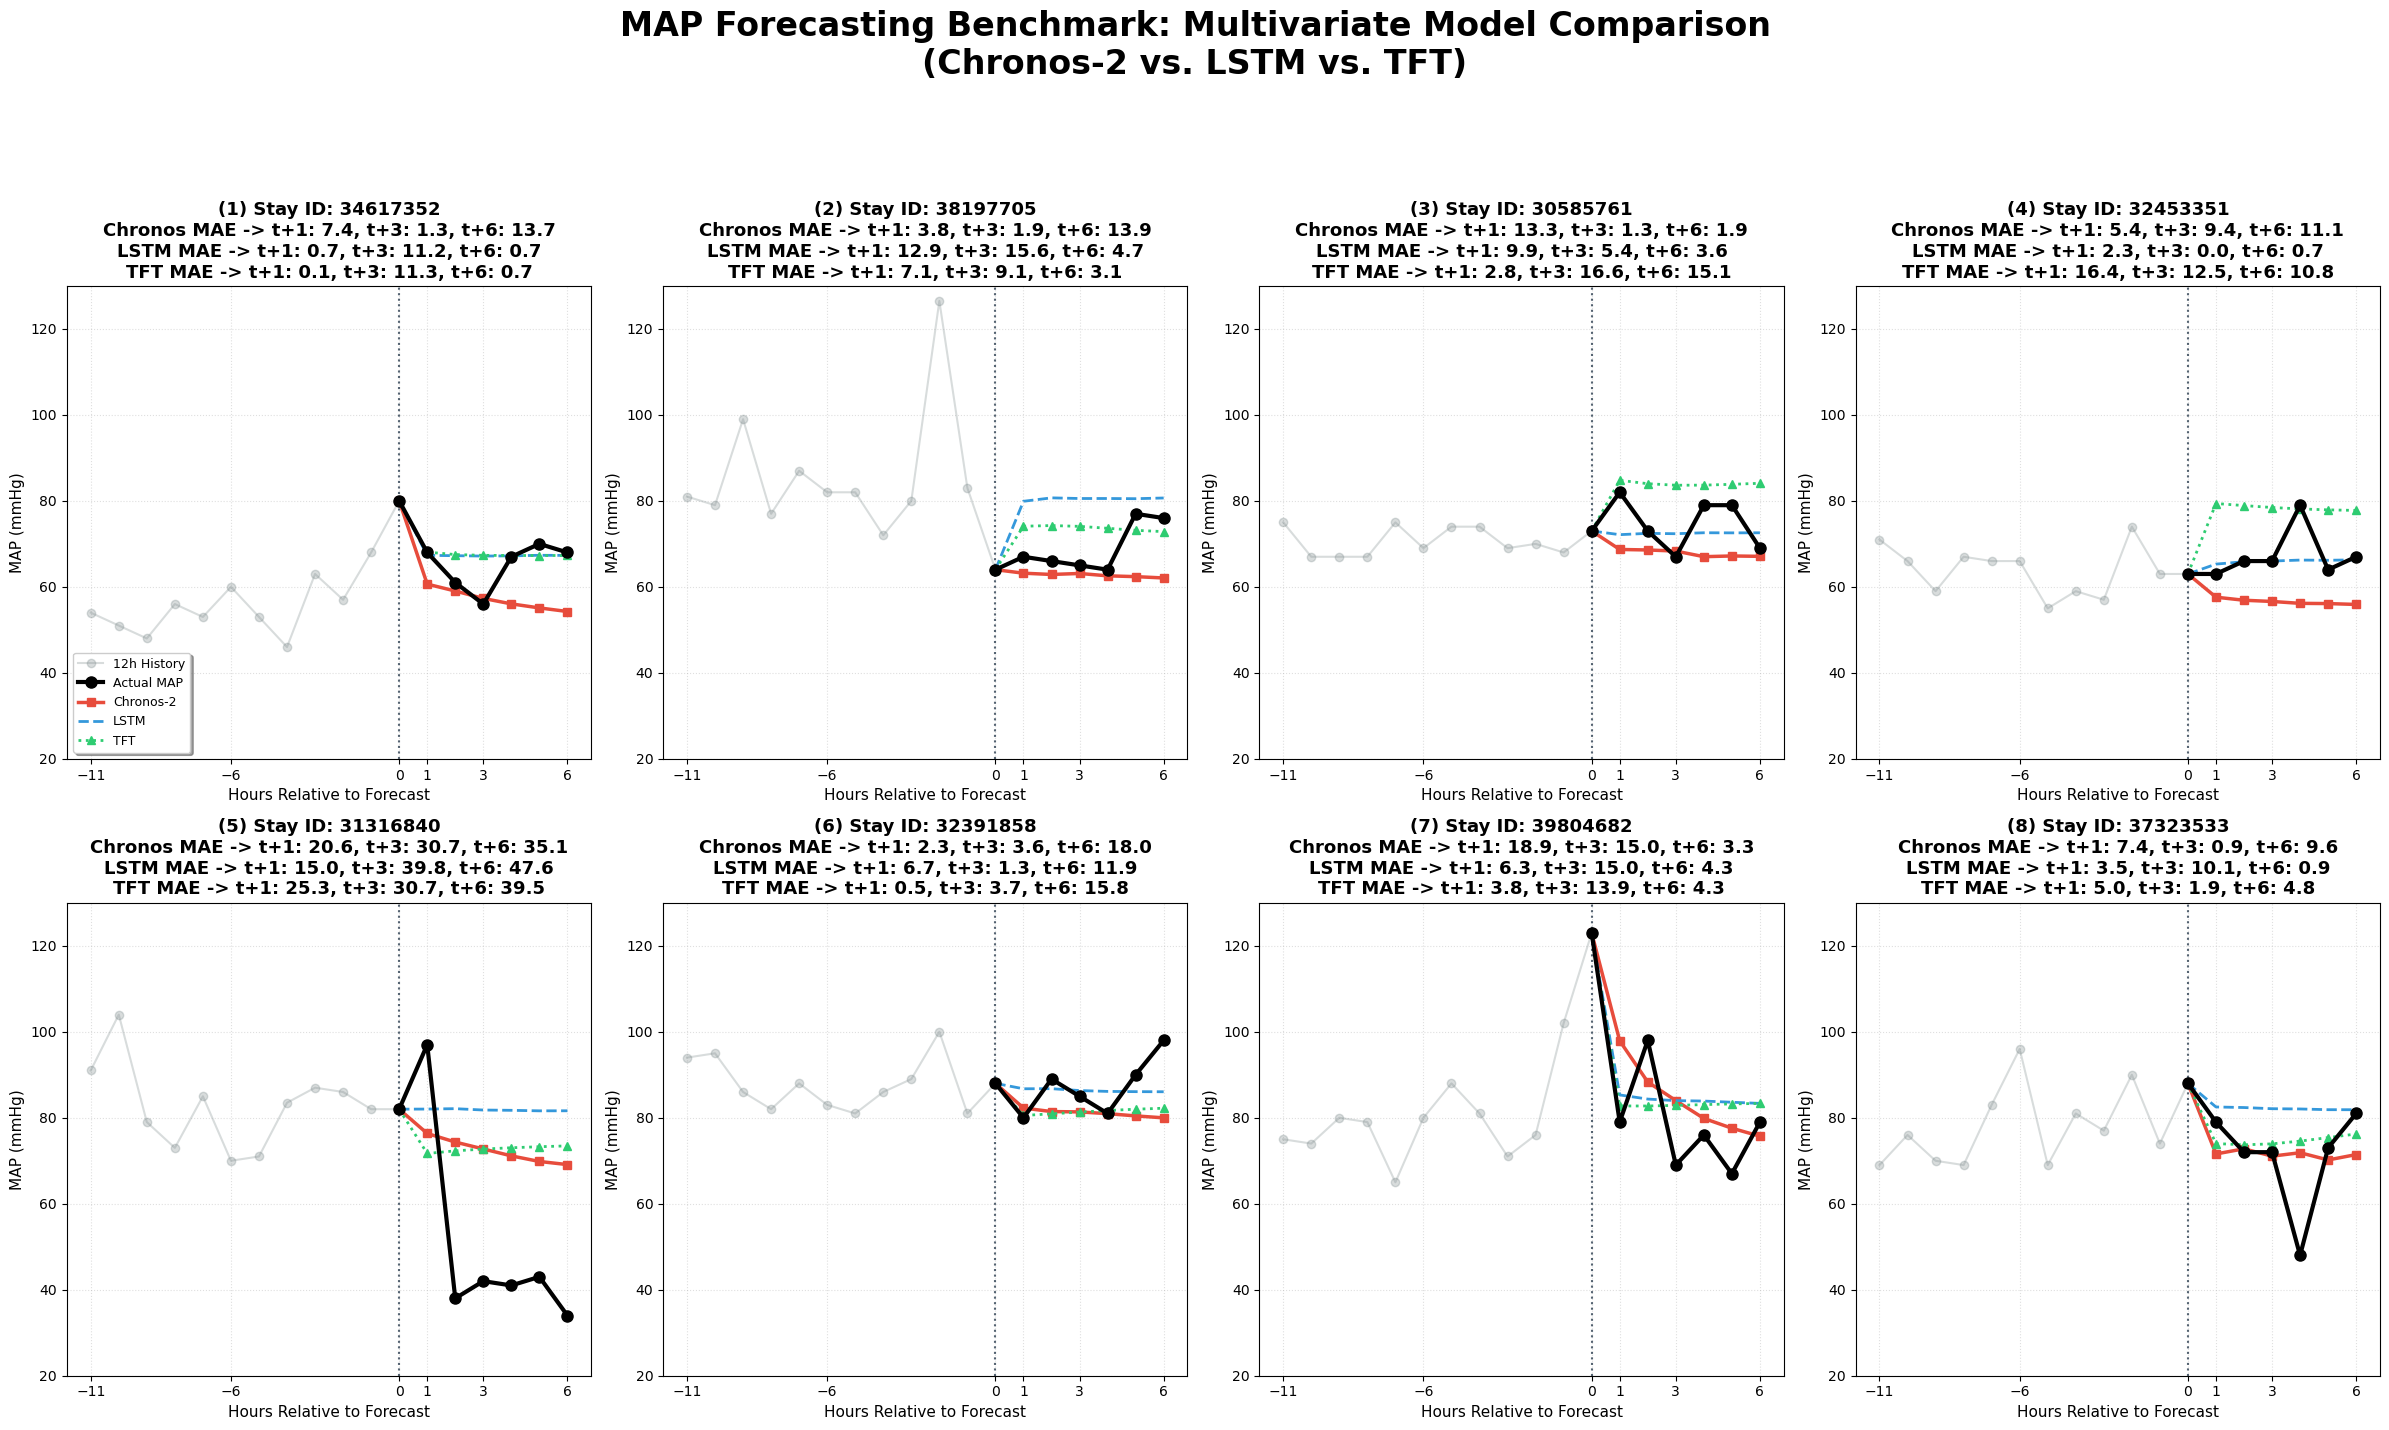

In [171]:
plot_final_multivariate_comparison(target_stay_ids, chronos_visual_df, lstm_visual_df, tft_visual_df, df_test)

##### **Comparative Performance Analysis: Chronos-2 vs. LSTM vs. TFT**

* **TFT Attention and Peaks:** The TFT model showed a unique ability to anticipate physiological "surges." In Plots 3 and 4, the TFT was the only model to correctly forecast a significant spike in MAP. However, it exhibited a "persistence bias," maintaining the predicted high values rather than capturing the subsequent physiological return to baseline or it captures it at the wrong timie period.
* **In-Depth Performance (Plots 4 & 5):**
    * **Plot 4 (Upward Trend):** This plot highlighted the starkest architectural contrast. While the **TFT** successfully predicted the magnitude of the spike, the **LSTM** only captured a minor, gradual increase. **Chronos-2** failed significantly, forecasting a sharp downward trajectory that completely diverged from the actual patient data.
    * **Plot 5 (Clinical Crash):** This served as a collective failure point for all architectures. The **LSTM** forecasted stability (nearly flat line), completely missing the impending drop. While **Chronos-2** and **TFT** both correctly identified a decrease, neither could capture the severity or depth of the sudden "crash," highlighting a limitation in predicting extreme physiological instability.
* **Predictive Depth & Recovery:** Across most samples (notably Plots 6 and 8), all models struggled to forecast secondary fluctuations. While they could often identify the primary $t+1$ shift, they generally failed to predict intermediate spikes or recovery phases occurring later in the 6-hour window. This suggests that while the models are effective "early warning" indicators for immediate instability, they currently lack the depth to map out full physiological trajectories.
* **Clinical Sensitivity:** Plot 7 highlights a scenario where all models reached a consensus on a downward trend, albeit with varying degrees of granularity. In Plot 8, the LSTM failed significantly, while the other two models correctly identified the dip but underestimated the "massive" nature of the drop, highlighting a consistent challenge in modeling extreme hemodynamic volatility.

#### **Future Work**

To build upon these findings and enhance the predictive reliability of our models, future research should focus on the following key areas:

1. **Dataset Expansion:** Scale beyond the current cohort by integrating the full **MIMIC-IV** dataset or aggregating diverse, standardized clinical sources. This will provide the necessary volume to train high-capacity models without severe overfitting.
2. **Feature Refinement:** Utilise **TFT Feature Importance** (VSN) to eliminate noisy or redundant variables. Developing a "leaner" feature set will reduce computational complexity and improve model generalization on smaller clinical datasets.
3. **Further Domain-Specific Feature Engineering:** Conduct further clinical research to identify high-impact physiological drivers, such as laboratory results or ventilator-derived waveforms, that were not included in the initial study.
4. **Algorithmic Benchmarking:** Expand the hyperparameter search space and explore a broader spectrum of models. This includes testing simpler statistical baselines like **ARIMA** or **Vector Autoregression (VAR)** to determine if deep learning consistently outperforms traditional time-series methods for this task.

## Reference
1) <a id="Ref1"></a>  Johnson, A. E. W., Bulgarelli, L., Shen, L., Gayles, A., Shammout, A., Horng, S., Pollard, T. J., Hao, S., Moody, B., Gow, B., Lehman, L. H., Celi, L. A., & Mark, R. G. (2023). MIMIC-IV, a freely accessible electronic health record dataset. Scientific Data, 10(1). https://doi.org/10.1038/s41597-022-01899-x

2) <a id="Ref2"></a>  Yoon, J. H., Jeanselme, V., Dubrawski, A., Hravnak, M., Pinsky, M. R., & Clermont, G. (2020). Prediction of hypotension events with physiologic vital sign signatures in the intensive care unit. Critical Care, 24(1). https://doi.org/10.1186/s13054-020-03379-3

3) <a id="Ref3"></a> Amazon Science. (2024). Introducing Chronos-2: From univariate to universal forecasting. Amazon Science Blog. https://www.amazon.science/blog/introducing-chronos-2-from-univariate-to-universal-forecasting